# GastroEval — Senior ML Engineering Master Prompt (vNext)

**Role:** Act as GPT-5.6 Luna operating as a senior ML/NLP engineer, evaluation scientist, and production ML reviewer.

## Objective
Build GastroEval as an explainable hybrid NLP + ML restaurant-review evaluation system. The system must produce aspect-level evidence, sentiment, a continuous 0–100 quality score, evidence confidence, strengths/weaknesses, and deployment artifacts.

## vNext requirements introduced after external stress testing

### A. Training augmentation
- Add the supplied Tatva review set as a small **supervised domain-adaptation augmentation** to the sentiment-training partition only.
- Use **9 explicitly labeled Tatva reviews: 8 Positive and 1 Negative**.
- Do not put these 9 reviews in validation/test.
- Do not use the remaining Tatva reviews in the uploaded source as model-fitting data; reserve them for external diagnostic stress testing.
- Keep the augmentation provenance explicit and save it separately.

### B. Longer linguistic context
The system must not rely primarily on isolated one/two-word matches.
- Use a **single TF-IDF representation with word 1–5 grams** so the classifier explicitly considers unigrams through five-word phrases while keeping inference compatible with the existing Streamlit artifact interface. Use a controlled vocabulary cap (`max_features`) for efficiency.
- Aspect context extraction should inspect a local clause of up to approximately 30 words, not only a tiny window.
- Rule matching must consider phrases up to 5 words and prioritize longer, more specific phrases over isolated words.

### C. Evaluation score
Every aspect-evidence record must have a continuous **Evaluation_Score (0–100)** derived from:
- model class probabilities;
- high-precision multi-word linguistic rules;
- rule confidence/strength.

The final aspect quality score must aggregate these continuous evaluation scores rather than only treating Positive=1, Neutral=0.5, Negative=0.

### D. Separate quality from confidence
- Quality answers: “What does the observed evidence say?”
- Confidence answers: “How much evidence do we have?”
- Low evidence must not automatically drag a strongly positive observed aspect to 50.
- Missing evidence is `Insufficient Evidence`, not negative evidence.

### E. Robust language handling
Explicitly test:
- `not the best`, `wasn't the best`, `nothing to brag about`, `below average`, `not upto mark`;
- `not great value`, `don't feel it offers good value`, `not value for money`;
- `overpriced`, `over priced`, `prices`, `costing`, `₹2500`, `2500 for 2`;
- `slow-cooked`, `slow-cooking` without treating `slow` as negative;
- service events: `delayed`, `jumbled order`, `no one attended`, `waited`, `arrived late`;
- positive hospitality language: `impeccable`, `pristine`, `royal`, `regal`, `lush`, `magical`, `10/10`, `above and beyond`;
- subtle/neutral language: `decent`, `okay`, `average`, `not bad`.

## Evaluation discipline
- Restaurant-grouped train/validation/test split.
- Test restaurants remain untouched until final evaluation.
- Hyperparameters selected only on validation data.
- External stress sets never affect fitting/model selection.
- Report Accuracy, Balanced Accuracy, Macro-F1 and per-class metrics.
- Report held-out restaurant-level Pearson/Spearman.
- Stress-test sparse 8–20 review inputs.
- Execute the complete notebook from a fresh kernel and finish with `FINAL NOTEBOOK VERIFICATION: PASSED`.
- Never claim “perfect”; document limitations and failure cases.


In [2]:
# =========================================================
# 1. Imports, reproducibility and paths
# =========================================================
from pathlib import Path
import os

# Keep notebook execution stable on low-memory/limited-CPU environments.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
import json
import re
import sys
import platform
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.pipeline import FeatureUnion
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "gastroeval_outputs"
ARTIFACT_DIR = BASE_DIR / "gastroeval_artifacts"
OUTPUT_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-5u1ix3xg because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Python: 3.13.5
Platform: Linux-6.18.44-x86_64-with-glibc2.41


In [3]:
# =========================================================
# 2. Load the dataset
# =========================================================
DATA_CANDIDATES = [
    Path("Restaurant reviews.csv"),
    Path("/mnt/data/Restaurant reviews.csv"),
]

DATA_PATH = next(
    (path for path in DATA_CANDIDATES if path.exists()),
    None
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Restaurant reviews.csv was not found. "
        "Place it beside the notebook."
    )

df = pd.read_csv(DATA_PATH)
df["Source_Row_ID"] = np.arange(len(df))

print("Dataset:", DATA_PATH.resolve())
print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))
display(df.head())

Dataset: /mnt/data/gastroeval_run2/Restaurant reviews.csv
Rows: 10,000
Columns: 8


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Source_Row_ID
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,1
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,2
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,3
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,4


In [4]:
# =========================================================
# 3. Data audit
# =========================================================
audit = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str).values,
    "Missing": df.isna().sum().values,
    "Missing_%": (df.isna().mean() * 100).round(2).values,
    "Unique": df.nunique(dropna=True).values,
})
display(audit)

print("Exact duplicate rows:", int(df.duplicated().sum()))
print("Unique businesses:", int(df["Restaurant"].nunique()))

df["Rating_numeric"] = pd.to_numeric(
    df["Rating"],
    errors="coerce"
)

invalid_ratings = df[
    df["Rating_numeric"].isna() & df["Rating"].notna()
]
print("Invalid/non-numeric ratings:", len(invalid_ratings))
display(invalid_ratings[["Restaurant", "Review", "Rating"]].head(10))

,Column,Dtype,Missing,Missing_%,Unique
0,Restaurant,object,0,0.00,100
1,Reviewer,object,38,0.38,7446
2,Review,object,45,0.45,9364
3,Rating,object,38,0.38,10
4,Metadata,object,38,0.38,2477
5,Time,object,38,0.38,9782
6,Pictures,int64,0,0.00,36
7,Source_Row_ID,int64,0,0.00,10000


Exact duplicate rows: 0
Unique businesses: 100
Invalid/non-numeric ratings: 1


,Restaurant,Review,Rating
7601,The Old Madras Baking Company,One of the best pizzas to try. It served with ...,Like


In [5]:
# =========================================================
# 4. Data cleaning and restaurant curation
# =========================================================
excluded_businesses = [
    "10 Downing Street",
    "Amul",
    "Cafe Eclat",
    "Club Rogue",
    "Cream Stone",
    "Domino's Pizza",
    "Driven Cafe",
    "Dunkin' Donuts",
    "Faasos",
    "Hunger Maggi Point",
    "KFC",
    "KS Bakers",
    "Karachi Bakery",
    "Karachi Cafe",
    "La La Land - Bar & Kitchen",
    "Labonel",
    "Momos Delight",
    "Mustang Terrace Lounge",
    "Over The Moon Brew Company",
    "PourHouse7",
    "Prism Club & Kitchen",
    "SKYHY",
    "Sardarji's Chaats & More",
    "Shah Ghouse Spl Shawarma",
    "Squeeze @ The Lime",
    "Tempteys",
    "The Chocolate Room",
    "The Lal Street - Bar Exchange",
    "The Old Madras Baking Company",
    "The Tilt Bar Republic",
    "Tiki Shack",
    "Yum Yum Tree - The Arabian Food Court",
    "Asian Meal Box",
    "Being Hungry",
    "Behrouz Biryani",
    "Biryanis And More",
    "Mohammedia Shawarma",
    "eat.fit",
]

# Records with neither review nor rating are unusable.
unusable = df["Review"].isna() & df["Rating_numeric"].isna()
df_clean = df.loc[~unusable].copy()

# Remove exact duplicates if present.
df_clean = df_clean.drop_duplicates(
    subset=[
        "Restaurant", "Reviewer", "Review", "Rating",
        "Metadata", "Time", "Pictures"
    ],
    keep="first"
).copy()

restaurant_df = df_clean[
    ~df_clean["Restaurant"].isin(excluded_businesses)
].copy()

restaurant_df["Review_clean"] = (
    restaurant_df["Review"]
    .astype("string")
    .str.strip()
)

restaurant_df["review_word_count"] = (
    restaurant_df["Review_clean"]
    .fillna("")
    .str.split()
    .str.len()
)

restaurant_df["review_char_count"] = (
    restaurant_df["Review_clean"]
    .fillna("")
    .str.len()
)

print("Raw rows:", len(df))
print("After unusable removal:", len(df_clean))
print("Curated restaurant rows:", len(restaurant_df))
print("Curated restaurants:", restaurant_df["Restaurant"].nunique())

Raw rows: 10000
After unusable removal: 9962
Curated restaurant rows: 6162
Curated restaurants: 62


Rating statistics:


,Value
count,6162.000000
mean,3.671292
std,1.472463
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


Review length statistics:


,Words
count,6162.000000
mean,51.383966
std,64.581732
min,0.000000
25%,25.000000
50%,34.000000
75%,58.000000
max,964.000000


Curated rating distribution:


,Count
Rating_numeric,
1.0,1003
1.5,3
2.0,412
2.5,15
3.0,724
3.5,23
4.0,1396
4.5,26
5.0,2560


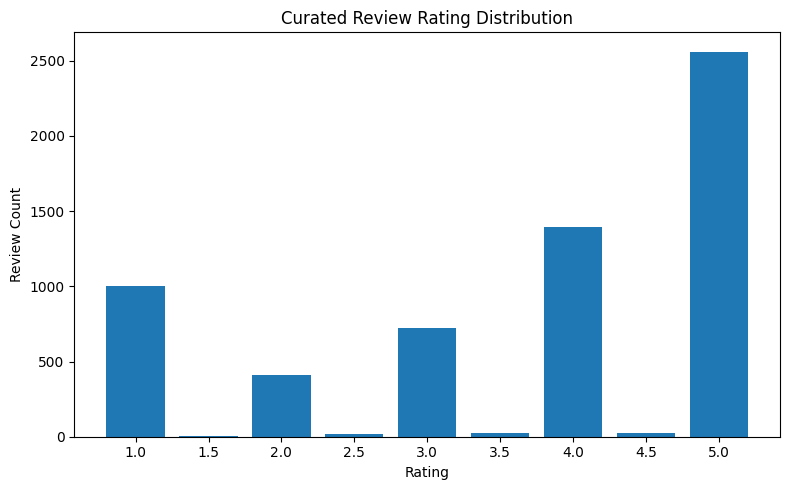

In [6]:
# =========================================================
# 5. Curated-data EDA
# =========================================================
rating_stats = restaurant_df["Rating_numeric"].describe()
print("Rating statistics:")
display(rating_stats.to_frame("Value"))

print("Review length statistics:")
display(
    restaurant_df["review_word_count"]
    .describe()
    .to_frame("Words")
)

print("Curated rating distribution:")
display(
    restaurant_df["Rating_numeric"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

fig, ax = plt.subplots(figsize=(8, 5))
counts = restaurant_df["Rating_numeric"].dropna().value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values)
ax.set_title("Curated Review Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Review Count")
plt.tight_layout()
plt.show()

## Primary three-class sentiment task

In [8]:
# =========================================================
# 6. ML target construction
# =========================================================
ml_df = restaurant_df[
    restaurant_df["Review_clean"].notna()
    & restaurant_df["Rating_numeric"].notna()
].copy()

def create_sentiment_class(rating):
    if rating <= 2:
        return "Negative"
    if rating <= 3:
        return "Neutral"
    return "Positive"

ml_df["sentiment_class"] = ml_df["Rating_numeric"].apply(
    create_sentiment_class
)

# Stable ordering for reproducibility.
ml_df = (
    ml_df
    .sort_values(
        ["Restaurant", "Review_clean", "Rating_numeric", "Source_Row_ID"],
        kind="mergesort"
    )
    .reset_index(drop=True)
)

print("ML-ready reviews:", len(ml_df))
display(
    ml_df["sentiment_class"]
    .value_counts()
    .reindex(["Negative", "Neutral", "Positive"])
    .to_frame("Count")
)

ML-ready reviews: 6158


,Count
sentiment_class,
Negative,1418
Neutral,738
Positive,4002


In [9]:
# =========================================================
# 7. Restaurant-grouped split + supervised Tatva augmentation
# =========================================================
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

ml_df["group_fold"] = -1

for fold, (_, idx) in enumerate(
    sgkf.split(
        ml_df,
        y=ml_df["sentiment_class"],
        groups=ml_df["Restaurant"],
    )
):
    ml_df.loc[idx, "group_fold"] = fold

TRAIN_FOLDS = [0, 2, 3]
VALIDATION_FOLD = 1
TEST_FOLD = 4

# Base split from the original restaurant dataset.
train_df = ml_df[ml_df["group_fold"].isin(TRAIN_FOLDS)].copy()
validation_df = ml_df[ml_df["group_fold"] == VALIDATION_FOLD].copy()
test_df = ml_df[ml_df["group_fold"] == TEST_FOLD].copy()

train_restaurants = set(train_df["Restaurant"])
validation_restaurants = set(validation_df["Restaurant"])
test_restaurants = set(test_df["Restaurant"])

assert train_restaurants.isdisjoint(validation_restaurants)
assert train_restaurants.isdisjoint(test_restaurants)
assert validation_restaurants.isdisjoint(test_restaurants)

# ------------------------------------------------------------------
# Tatva supervised domain-adaptation augmentation.
# These are the 9 requested labelled reviews from the supplied TATVA.txt:
# 8 positive + 1 negative. They are added only to sentiment training.
# ------------------------------------------------------------------
TATVA_AUGMENTATION_REVIEWS = [
    "I recently visited Tatva and had an overall decent experience. The ambience of the place was pleasant and comfortable, making it a good option for group outings and casual dining",
    "The ambience sets the tone the moment you walk in-elegant, warm, and thoughtfully put together. But honestly, it’s the food you’ll be thinking about on the way home.",
    "We ordered across the menu, and almost everything delivered: Jalapeño Poppers – crispy, punchy, and well-balanced. A strong start. (4.5/5) Veg Manchow Soup – solid and comforting. (4/5)",
    "Tatva Restaurant in Jubilee Hills offers a high-quality dining experience with a strong focus on hospitality. While it took a little time to find the perfect table, the wait was quickly forgotten once the meal arrived. The food is consistently good, but the standout feature is the exceptional service.",
    "Visited Tatva, Jubilee Hills recently. The ambience is decent and comfortable, and the service was excellent. The staff was courteous, attentive, and ensured a pleasant dining experience. However, the food was average and did not quite match the expectations considering the pricing.",
    "Food, Service, Ambience and everything was just perfect. Best Palak Panner ever in hyderabad. Will definitely come back for palak panner",
    "The culinary experience was truly exceptional, a delightful journey for the palate from beginning to end. Every dish, from the intriguing starters that piqued our curiosity to the substantial main course that satisfied our deepest cravings, was simply outstanding.",
    "the overall experience is worth it. The ambiance is amazing, the food tastes great, and the staff is extremely cooperative, courteous, and helpful. A good place to visit with family and friends",
    "Was happy with the food taste , but service was very slow.. we have visited as group of 20 but only 1 person was serving everything though there were lot of staff to support. Every dish by the time it was served to everyone it became cold",
]
TATVA_AUGMENTATION_LABELS = ["Positive"] * 8 + ["Negative"]

tatva_aug_df = pd.DataFrame({
    "Source_Row_ID": np.arange(-900000, -900000 - len(TATVA_AUGMENTATION_REVIEWS), -1),
    "Restaurant": ["Tatva (Supervised Augmentation)"] * len(TATVA_AUGMENTATION_REVIEWS),
    "Review_clean": TATVA_AUGMENTATION_REVIEWS,
    "Rating_numeric": np.nan,
    "sentiment_class": TATVA_AUGMENTATION_LABELS,
    "group_fold": -1,
    "Augmentation_Source": "TATVA.txt supplied by user",
})

# This dataframe is used only by the sentiment classifier.
sentiment_train_df = pd.concat(
    [
        train_df[["Source_Row_ID", "Restaurant", "Review_clean", "Rating_numeric", "sentiment_class", "group_fold"]].copy(),
        tatva_aug_df[["Source_Row_ID", "Restaurant", "Review_clean", "Rating_numeric", "sentiment_class", "group_fold"]].copy(),
    ],
    ignore_index=True,
)

# Small weighting prevents the 9-example domain set from disappearing inside ~3.7k reviews.
TATVA_SAMPLE_WEIGHT = 2.0
sentiment_sample_weight = np.concatenate([
    np.ones(len(train_df), dtype=float),
    np.full(len(tatva_aug_df), TATVA_SAMPLE_WEIGHT, dtype=float),
])

assert len(sentiment_train_df) == len(train_df) + len(tatva_aug_df)
assert sentiment_train_df["sentiment_class"].tail(9).tolist() == TATVA_AUGMENTATION_LABELS

print("Base train:", len(train_df), "reviews /", len(train_restaurants), "restaurants")
print("Tatva augmentation:", len(tatva_aug_df), "reviews (8 Positive + 1 Negative)")
print("Sentiment-training size:", len(sentiment_train_df))
print("Validation:", len(validation_df), "reviews /", len(validation_restaurants), "restaurants")
print("Test:", len(test_df), "reviews /", len(test_restaurants), "restaurants")
print("Restaurant-overlap check: PASSED")

tatva_aug_df.to_csv(OUTPUT_DIR / "TATVA_training_augmentation.csv", index=False)


Base train: 3676 reviews / 37 restaurants
Tatva augmentation: 9 reviews (8 Positive + 1 Negative)
Sentiment-training size: 3685
Validation: 1284 reviews / 13 restaurants
Test: 1198 reviews / 12 restaurants
Restaurant-overlap check: PASSED


In [10]:
# =========================================================
# 8. Split distribution + leakage audit
# =========================================================
def distribution(data):
    return (
        data["sentiment_class"]
        .value_counts(normalize=True)
        .reindex(["Negative", "Neutral", "Positive"])
        .fillna(0)
        .mul(100)
        .round(2)
    )

display(pd.DataFrame({
    "Train_%": distribution(train_df),
    "Validation_%": distribution(validation_df),
    "Test_%": distribution(test_df),
}))

train_texts = set(train_df["Review_clean"])
val_texts = set(validation_df["Review_clean"])
test_texts = set(test_df["Review_clean"])

print("Exact text overlap Train/Validation:", len(train_texts & val_texts))
print("Exact text overlap Train/Test:", len(train_texts & test_texts))
print("Exact text overlap Validation/Test:", len(val_texts & test_texts))

,Train_%,Validation_%,Test_%
sentiment_class,,,
Negative,22.85,22.35,24.29
Neutral,11.92,11.99,12.19
Positive,65.23,65.65,63.52


Exact text overlap Train/Validation: 14
Exact text overlap Train/Test: 36
Exact text overlap Validation/Test: 17


In [11]:
# =========================================================
# 9. Sentiment task + 1–5-gram TF-IDF representation
# =========================================================
X_train = sentiment_train_df["Review_clean"].astype(str)
y_train = sentiment_train_df["sentiment_class"]
X_val = validation_df["Review_clean"].astype(str)
y_val = validation_df["sentiment_class"]
X_test = test_df["Review_clean"].astype(str)
y_test = test_df["sentiment_class"]

majority_class = y_train.mode()[0]
majority_pred = np.full(len(y_val), majority_class)

baseline_metrics = {
    "Model": "Majority baseline",
    "Accuracy": accuracy_score(y_val, majority_pred),
    "Balanced_Accuracy": balanced_accuracy_score(y_val, majority_pred),
    "Macro_F1": f1_score(y_val, majority_pred, average="macro"),
}
display(pd.DataFrame([baseline_metrics]).round(4))

# The sentiment model now explicitly considers 1, 2, 3, 4 and 5-word phrases.
TFIDF_PARAMS = {
    "lowercase": True,
    "strip_accents": "unicode",
    "ngram_range": (1, 5),
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": True,
    "max_features": 40000,
}
print("Final lexical context: 1–5 word TF-IDF n-grams; max features:", TFIDF_PARAMS["max_features"])


,Model,Accuracy,Balanced_Accuracy,Macro_F1
0,Majority baseline,0.6565,0.3333,0.2642


Final lexical context: 1–5 word TF-IDF n-grams; max features: 40000


In [12]:
# =========================================================
# 10. Controlled hyperparameter tuning on validation only
# =========================================================
tuning_vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
X_train_tfidf = tuning_vectorizer.fit_transform(X_train)
X_val_tfidf = tuning_vectorizer.transform(X_val)

print("TF-IDF training matrix:", X_train_tfidf.shape)

C_VALUES = [0.5, 1.0, 2.0]
tuning_rows = []

for C in C_VALUES:
    model = LogisticRegression(
        C=C,
        max_iter=2500,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    model.fit(
        X_train_tfidf,
        y_train,
        sample_weight=sentiment_sample_weight,
    )
    pred = model.predict(X_val_tfidf)

    tuning_rows.append({
        "C": C,
        "Features": X_train_tfidf.shape[1],
        "Accuracy": accuracy_score(y_val, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, pred),
        "Macro_F1": f1_score(y_val, pred, average="macro"),
        "Neutral_F1": f1_score(
            y_val, pred, labels=["Neutral"], average="macro", zero_division=0
        ),
    })

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values("Macro_F1", ascending=False)
    .reset_index(drop=True)
)
display(tuning_results.round(4))
SELECTED_C = float(tuning_results.iloc[0]["C"])
print("Selected C based on validation Macro-F1:", SELECTED_C)


TF-IDF training matrix: (3685, 40000)


,C,Features,Accuracy,Balanced_Accuracy,Macro_F1,Neutral_F1
0,1.0,40000,0.8396,0.7762,0.7545,0.5070
1,2.0,40000,0.8427,0.7664,0.7512,0.5045
2,0.5,40000,0.8302,0.7760,0.7484,0.5041


Selected C based on validation Macro-F1: 1.0


In [13]:
# =========================================================
# 11. Selected sentiment model
# =========================================================
selected_vec = tuning_vectorizer
Xtr_selected = X_train_tfidf
Xv_selected = X_val_tfidf

selected_model = LogisticRegression(
    C=SELECTED_C,
    max_iter=2500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
selected_model.fit(
    Xtr_selected,
    y_train,
    sample_weight=sentiment_sample_weight,
)
selected_val_pred = selected_model.predict(Xv_selected)

print(classification_report(
    y_val,
    selected_val_pred,
    labels=["Negative", "Neutral", "Positive"],
    zero_division=0,
))

display(pd.DataFrame([{
    "Accuracy": accuracy_score(y_val, selected_val_pred),
    "Balanced_Accuracy": balanced_accuracy_score(y_val, selected_val_pred),
    "Macro_F1": f1_score(y_val, selected_val_pred, average="macro"),
}]).round(4))


              precision    recall  f1-score   support

    Negative       0.83      0.87      0.85       287
     Neutral       0.45      0.58      0.51       154
    Positive       0.95      0.88      0.91       843

    accuracy                           0.84      1284
   macro avg       0.74      0.78      0.75      1284
weighted avg       0.86      0.84      0.85      1284



,Accuracy,Balanced_Accuracy,Macro_F1
0,0.8396,0.7762,0.7545


In [14]:
# =========================================================
# 12. Held-out test evaluation
# =========================================================
# Test restaurants are still completely untouched by model fitting and selection.
holdout_vec = selected_vec
Xt_holdout = holdout_vec.transform(X_test)
holdout_model = selected_model

holdout_val_pred = selected_val_pred
holdout_test_pred = holdout_model.predict(Xt_holdout)

ml_metrics = pd.DataFrame([
    {
        "Split": "Validation",
        "Accuracy": accuracy_score(y_val, holdout_val_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, holdout_val_pred),
        "Macro_F1": f1_score(y_val, holdout_val_pred, average="macro"),
    },
    {
        "Split": "Held-out Test",
        "Accuracy": accuracy_score(y_test, holdout_test_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, holdout_test_pred),
        "Macro_F1": f1_score(y_test, holdout_test_pred, average="macro"),
    },
])

display(ml_metrics.round(4))
print("Held-out test classification report:")
print(classification_report(
    y_test,
    holdout_test_pred,
    labels=["Negative", "Neutral", "Positive"],
    zero_division=0,
))


,Split,Accuracy,Balanced_Accuracy,Macro_F1
0,Validation,0.8396,0.7762,0.7545
1,Held-out Test,0.8431,0.7653,0.7548


Held-out test classification report:
              precision    recall  f1-score   support

    Negative       0.82      0.87      0.84       291
     Neutral       0.49      0.53      0.51       146
    Positive       0.93      0.89      0.91       761

    accuracy                           0.84      1198
   macro avg       0.75      0.77      0.75      1198
weighted avg       0.85      0.84      0.85      1198



In [15]:
# =========================================================
# 13. Test error analysis
# =========================================================
test_review_predictions = test_df[
    [
        "Source_Row_ID",
        "Restaurant",
        "Review_clean",
        "Rating_numeric",
        "sentiment_class",
    ]
].copy()

test_review_predictions["Predicted_Sentiment"] = holdout_test_pred
test_review_predictions["Correct"] = (
    test_review_predictions["sentiment_class"]
    == test_review_predictions["Predicted_Sentiment"]
)
test_review_predictions["Review_Length"] = (
    test_review_predictions["Review_clean"]
    .fillna("")
    .str.split()
    .str.len()
)

print("Test error rate:",
      round((~test_review_predictions["Correct"]).mean() * 100, 2), "%")

display(
    test_review_predictions[
        ["sentiment_class", "Predicted_Sentiment"]
    ].value_counts()
    .rename("Count")
    .to_frame()
)

display(
    test_review_predictions[
        ~test_review_predictions["Correct"]
    ][
        [
            "Restaurant",
            "Review_clean",
            "Rating_numeric",
            "sentiment_class",
            "Predicted_Sentiment",
        ]
    ].head(30)
)

Test error rate: 15.69 %


Count
sentiment_class Predicted_Sentiment       
Positive        Positive               679
Negative        Negative               253
Neutral         Neutral                 78
Positive        Neutral                 56
Neutral         Positive                38
                Negative                30
Negative        Neutral                 26
Positive        Negative                26
Negative        Positive                12

,Restaurant,Review_clean,Rating_numeric,sentiment_class,Predicted_Sentiment
5,13 Dhaba,"Amazing taste. Ordered Chole, Paneer dish and ...",3.0,Neutral,Negative
6,13 Dhaba,Awesome kulcha with kaali dal & raita. Paneer ...,4.0,Positive,Neutral
18,13 Dhaba,Food was good,4.0,Positive,Neutral
25,13 Dhaba,Have ordered from this place a couple of times...,4.0,Positive,Neutral
30,13 Dhaba,I have been here a while back and it was reall...,4.0,Positive,Neutral
38,13 Dhaba,I ordered butter rotis but got plain rotis and...,4.0,Positive,Negative
41,13 Dhaba,I would recommend this place for ordering purp...,3.0,Neutral,Positive
44,13 Dhaba,"Located near the Gachibowli ORR circle ""13 DHA...",4.0,Positive,Neutral
47,13 Dhaba,"Okay, so I am not a veg person usually, but th...",4.0,Positive,Negative
59,13 Dhaba,Quantity of the food is very less for a single...,2.0,Negative,Neutral


In [16]:
# =========================================================
# 14. Test performance by review length
# =========================================================
test_review_predictions["Length_Category"] = pd.cut(
    test_review_predictions["Review_Length"],
    bins=[-1, 5, 10, 25, 50, 100, np.inf],
    labels=["1–5", "6–10", "11–25", "26–50", "51–100", "100+"],
)

length_rows = []

for category, group in test_review_predictions.groupby(
    "Length_Category",
    observed=False,
):
    if len(group) == 0:
        continue

    length_rows.append({
        "Length": str(category),
        "Reviews": len(group),
        "Accuracy": accuracy_score(
            group["sentiment_class"],
            group["Predicted_Sentiment"],
        ),
        "Macro_F1": f1_score(
            group["sentiment_class"],
            group["Predicted_Sentiment"],
            average="macro",
            zero_division=0,
        ),
    })

test_length_metrics = pd.DataFrame(length_rows)
display(test_length_metrics.round(3))

,Length,Reviews,Accuracy,Macro_F1
0,1–5,316,0.842,0.663
1,6–10,59,0.797,0.696
2,11–25,122,0.844,0.707
3,26–50,422,0.874,0.791
4,51–100,180,0.861,0.825
5,100+,99,0.707,0.677


## Secondary ML models

In [18]:
# =========================================================
# 15. Five-class rating classification (original rated data only)
# =========================================================
ml_df["rating_class_5"] = np.floor(
    ml_df["Rating_numeric"] + 0.5
).astype(int)

train_df = ml_df[ml_df["group_fold"].isin(TRAIN_FOLDS)].copy()
validation_df = ml_df[ml_df["group_fold"] == VALIDATION_FOLD].copy()
test_df = ml_df[ml_df["group_fold"] == TEST_FOLD].copy()

rating_vectorizer = TfidfVectorizer(**{
    "lowercase": True,
    "strip_accents": "unicode",
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": True,
    "max_features": 50000,
})
Xtr_rating = rating_vectorizer.fit_transform(train_df["Review_clean"].astype(str))
Xv_rating = rating_vectorizer.transform(validation_df["Review_clean"].astype(str))
Xt_rating = rating_vectorizer.transform(test_df["Review_clean"].astype(str))

rating_model = LogisticRegression(
    C=SELECTED_C,
    max_iter=2500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
rating_model.fit(Xtr_rating, train_df["rating_class_5"])

rating_val_pred = rating_model.predict(Xv_rating)
rating_test_pred = rating_model.predict(Xt_rating)

rating_metrics = pd.DataFrame([
    {
        "Split": "Validation",
        "Accuracy": accuracy_score(validation_df["rating_class_5"], rating_val_pred),
        "Balanced_Accuracy": balanced_accuracy_score(validation_df["rating_class_5"], rating_val_pred),
        "Macro_F1": f1_score(validation_df["rating_class_5"], rating_val_pred, average="macro", zero_division=0),
    },
    {
        "Split": "Held-out Test",
        "Accuracy": accuracy_score(test_df["rating_class_5"], rating_test_pred),
        "Balanced_Accuracy": balanced_accuracy_score(test_df["rating_class_5"], rating_test_pred),
        "Macro_F1": f1_score(test_df["rating_class_5"], rating_test_pred, average="macro", zero_division=0),
    },
])

display(rating_metrics.round(4))


,Split,Accuracy,Balanced_Accuracy,Macro_F1
0,Validation,0.6308,0.5639,0.5589
1,Held-out Test,0.6661,0.5703,0.5684


In [19]:
# =========================================================
# 16. Rating regression (original labeled train only)
# =========================================================
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(
    Xtr_rating,
    train_df["Rating_numeric"].astype(float)
)

reg_val_pred = ridge_model.predict(Xv_rating)
reg_test_pred = ridge_model.predict(Xt_rating)

reg_metrics = pd.DataFrame([
    {
        "Split": "Validation",
        "MAE": mean_absolute_error(validation_df["Rating_numeric"], reg_val_pred),
        "RMSE": np.sqrt(mean_squared_error(validation_df["Rating_numeric"], reg_val_pred)),
        "R2": r2_score(validation_df["Rating_numeric"], reg_val_pred),
    },
    {
        "Split": "Held-out Test",
        "MAE": mean_absolute_error(test_df["Rating_numeric"], reg_test_pred),
        "RMSE": np.sqrt(mean_squared_error(test_df["Rating_numeric"], reg_test_pred)),
        "R2": r2_score(test_df["Rating_numeric"], reg_test_pred),
    },
])

display(reg_metrics.round(4))


,Split,MAE,RMSE,R2
0,Validation,0.6431,0.8229,0.6733
1,Held-out Test,0.6404,0.8374,0.6874


## Improved aspect inference

The deployment layer now treats aspect extraction and sentiment as two separate decisions.

1. Identify the relevant aspect trigger.
2. Select the smallest useful local clause/context around that trigger.
3. Apply explicit restaurant-language and negation rules.
4. Use the trained TF-IDF + Logistic Regression model as the fallback.
5. Store the decision source and confidence for auditability.

This addresses the earlier whole-review vs. short-context mismatch without pretending that the classifier itself is an end-to-end ABSA model.

In [21]:
# =========================================================
# 17. High-precision aspect ontology and patterns
# =========================================================
ASPECTS = [
    "Food Quality",
    "Service",
    "Ambience",
    "Value for Money",
    "Hygiene",
    "Overall Dining Experience",
]

# The ontology deliberately includes restaurant-domain event language,
# morphological variants, and novel descriptive vocabulary.
ASPECT_TRIGGERS = {
    "Food Quality": [
        "food", "food quality", "dish", "dishes", "meal", "cuisine", "taste", "tasty",
        "delicious", "flavour", "flavor", "flavourful", "flavorful", "tasteless",
        "bland", "stale", "freshly prepared", "cooking", "cooked", "slow-cooked",
        "slow cooked", "slow-cooking", "slow cooking", "undercooked", "overcooked",
        "over done", "overdone", "dry", "raw", "tough", "burnt", "oily", "salty",
        "spicy", "starter", "starters", "main course", "dessert", "desserts",
        "biryani", "kebab", "kebabs", "pulao", "pasta", "pizza", "rasam", "curry",
        "curries", "stew", "fish", "prawn", "prawns", "mutton", "chicken", "rice",
        "bread", "breads", "appam", "seafood", "portion", "portions", "quantity",
        "authentic", "quality", "show stopper", "show-stopper", "lip smacking", "below average", "nothing to brag about", "not up to mark", "not upto mark", "banging", "out of this world", "most authentic",
    ],
    "Service": [
        "service", "services", "hospitality", "staff", "server", "servers", "waiter",
        "waiters", "waitress", "manager", "attentive", "courteous", "polite",
        "helpful", "prompt", "quick service", "slow service", "poor service",
        "bad service", "waiting", "waited", "waiting time", "delayed", "delay",
        "jumbled order", "order was jumbled", "order was delayed", "no one attended",
        "no one really attended", "unattended", "attended to the table", "rushed",
        "disorganized", "disorganised", "response", "served", "serving",
        "arrived late", "arrived 10 mins late", "finger bowls", "service timing",
        "service team", "guided us through the menu", "knowledgeable", "fine dining etiquette",
        "above and beyond", "well-trained", "well trained", "no one attended", "no one attended to the table", "order jumbled", "order jumbled up", "follow ups", "multiple follow-ups",
    ],
    "Ambience": [
        "ambience", "ambiance", "atmosphere", "decor", "decoration", "nawabi decor",
        "royal ambiance", "royal ambience", "regal ambiance", "regal ambience",
        "majestic ambiance", "majestic ambience", "royal vibe", "beautiful royal vibe",
        "lush", "green", "peaceful", "elegant", "inviting", "garden", "garden-like",
        "garden like", "interior", "interior design", "lighting", "music", "seating",
        "dining hall", "dining room", "surroundings", "view", "architecture",
        "aesthetic", "aesthetic arrangements", "vibe", "cozy", "cosy", "quiet",
        "spacious", "crowded", "cramped", "intimate", "relaxing", "romantic",
        "well-maintained", "well maintained", "hidden away", "hustle bustle",
        "scale of the dining room", "lush", "green", "peaceful", "welcoming", "calming", "soothing", "unmatched", "special atmosphere",
    ],
    "Value for Money": [
        "value for money", "value", "price", "prices", "pricing", "price tag", "cost",
        "costs", "costing", "expensive", "overpriced", "over priced", "exorbitant",
        "exorbitant price", "exorbitant price tag", "steep", "steep price", "reasonable",
        "reasonable price", "reasonable pricing", "affordable", "cheap", "worth",
        "worth the price", "worth the money", "worth every rupee", "worth every single rupee",
        "money's worth", "money’s worth", "not worth", "poor value", "low on value",
        "high value for money", "complete value for money", "good value for money",
        "portion", "portions", "quantity", "less quantity", "inflated", "inflated prices",
        "higher side", "high side", "high price", "bill", "fortune", "burn a hole",
        "ridiculous price", "absurd price", "daylight looting", "bucks", "rupees",
        "₹", "₹2500", "₹ 2500", "rupees", "bucks", "pricing is", "prices are", "price is", "costing", "cost to quantity", "price to quality", "cost-to-quantity", "worth trying",
    ],
    "Hygiene": [
        "hygiene", "hygienic", "cleanliness", "sanitation", "sanitized", "sanitised",
        "clean", "spotless", "spotlessly clean", "pristine", "immaculate", "sparkling clean",
        "dust-free", "dust free", "flawlessly clean", "stringent hygiene",
        "hygiene standards", "hygiene practices", "food safety", "sanitized menus",
        "clean restrooms", "restrooms", "restroom", "washroom", "toilet", "table linens",
        "silverware", "hot towels", "safe", "safety", "polished", "dirty", "unclean",
        "unhygienic", "contaminated", "foul smell", "bad smell", "hair in food",
        "hair", "insect", "cockroach", "fly in", "dust", "dust-free",
    ],
    "Overall Dining Experience": [
        "overall dining experience", "dining experience", "overall experience", "experience",
        "dining at", "eating at", "visit", "visiting", "revisit", "revisiting",
        "go back", "come back", "look forward to going back", "recommend", "recommended",
        "highly recommend", "will recommend", "must try", "must visit", "satisfied",
        "delightful experience", "amazing experience", "memorable", "special occasion",
        "night to remember", "magical", "nothing short of magical", "10/10",
        "once-in-a-lifetime", "once in a lifetime", "royal feast", "feel like royalty",
        "feel like absolute royalty", "worth every rupee", "outstanding", "top-notch",
        "absolutely fantastic", "absolutely amazing", "walked out", "not coming back",
        "won't come back", "wouldn't come back", "disappointing experience",
    ],
}

ASPECT_POSITIVE_TERMS = {
    "Food Quality": {
        "good","great","excellent","amazing","awesome","delicious","tasty","wonderful",
        "perfect","fantastic","best","nice","rich","tender","soft","juicy","fresh",
        "flavourful","flavorful","satisfying","quality","exceptional","authentic",
        "banging","show","show-stopper","lip","smacking","perfection","out","world",
        "beautifully","well-presented","well","prepared","consistent","consistently",
        "delightful","refined",
    },
    "Service": {
        "good","great","excellent","amazing","awesome","wonderful","perfect","fantastic",
        "best","nice","friendly","courteous","prompt","quick","attentive","impeccable",
        "exceptional","exemplary","legendary","knowledgeable","warm","polite","helpful",
        "trained","genuinely","above","beyond","benchmark","hospitality","sincerely",
        "kind","cared","caring","efficient","refined",
    },
    "Ambience": {
        "good","great","excellent","amazing","awesome","wonderful","perfect","fantastic",
        "best","nice","pleasant","royal","regal","magnificent","majestic","spectacular",
        "beautiful","gorgeous","elegant","luxurious","relaxing","unmatched","quiet",
        "romantic","grand","special","aesthetic","lush","green","peaceful","inviting",
        "cozy","cosy","spacious","refined","modern","well-maintained","maintained",
        "hidden","calm","serene",
    },
    "Value for Money": {
        "good","great","excellent","reasonable","affordable","cheap","worth","worthwhile",
        "justified","fair","balances","balanced","complete","high","value","money",
        "quality","matching","decent",
    },
    "Hygiene": {
        "good","great","excellent","amazing","impeccable","spotless","pristine","immaculate",
        "sanitized","sanitised","clean","cleanliness","hygienic","sparkling","stringent",
        "safe","flawless","top-notch","top","polished","fresh","dust-free","maintained",
        "well-maintained",
    },
    "Overall Dining Experience": {
        "good","great","excellent","amazing","awesome","wonderful","perfect","fantastic",
        "best","nice","pleasant","magical","flawless","unparalleled","special","memorable",
        "magnificent","royal","gorgeous","relaxing","recommended","recommend","enjoyed",
        "enjoy","love","10","night","remember","quality","royalty","outstanding",
        "top-notch","delightful","satisfied","amazing","refined",
    },
}

ASPECT_NEGATIVE_TERMS = {
    "Food Quality": {
        "bad","worst","poor","terrible","horrible","pathetic","awful","stale","bland","oily",
        "salty","cold","disappointing","disappointed","tough","raw","burnt","tasteless",
        "small","overcooked","undercooked","dry","overdone","below","average","flavourless",
        "flavorless","shitty","weird","strange","lacked","nothing","brag","mark","disappointing",
        "not",
    },
    "Service": {
        "bad","worst","poor","terrible","horrible","pathetic","awful","slow","rude","cold",
        "disappointing","disappointed","frustrating","disorganized","disorganised","rushed",
        "less","ignored","late","waiting","delayed","delay","jumbled","unattended","unresponsive",
        "poorly","messy","forgot","forgotten",
    },
    "Ambience": {
        "bad","worst","poor","terrible","horrible","pathetic","awful","cramped","crowded",
        "uncomfortable","disappointing","less","rushed","noisy",
    },
    "Value for Money": {
        "bad","worst","poor","terrible","awful","expensive","overpriced","exorbitant","costly",
        "steep","small","less","low","disappointing","disappointed","dent","fortune","burn",
        "hole","inflated","ridiculous","absurd","strange","daylight","looting","not","high",
    },
    "Hygiene": {
        "bad","worst","poor","terrible","horrible","pathetic","awful","dirty","unclean",
        "unhygienic","contaminated","foul","smell","hair","insect","cockroach","dust",
        "unsafe",
    },
    "Overall Dining Experience": {
        "bad","worst","poor","terrible","horrible","pathetic","awful","disappointing",
        "disappointed","ruined","frustrating","not","never","avoid","walked","leaving",
        "notwithstanding", "not worth it", "waste of money", "waste of money", "avoid this place", "never again",
    },
}

# High-precision phrase overrides. Negative constructions always run first.
STRONG_NEGATIVE_PHRASES = [
    "not the best", "wasn't the best", "was not the best", "not a bad place", "not bad",
    "nothing to brag about", "below average", "not up to mark", "not upto mark", "not up-to-mark",
    "less than good", "less than great", "not really impressed", "not impressed",
    "not value for money", "not good value", "not great value", "not worth the money",
    "don't feel it offers good value", "dont feel it offers good value",
    "do not feel it offers good value", "doesn't offer good value", "doesnt offer good value",
    "does not offer good value", "does not translate to good value", "doesn't translate to good value",
    "didn't get my money's worth", "didnt get my money's worth",
    "wouldn't call this value for money", "wouldnt call this value for money",
    "poor value for money", "absolutely poor value for money", "terrible value",
    "terrible value for money", "extremely overpriced", "highly overpriced", "incredibly overpriced",
    "over priced", "steep price", "quite expensive", "too expensive", "high price", "price was high", "price is high", "prices were high", "prices are high",
    "higher side", "high side", "prices are so inflated", "price is very high",
    "burn a hole in your pocket", "burn a hole in your pockets", "massive dent",
    "very slow", "exceptionally slow", "extremely slow", "slow service", "poor service",
    "bad service", "rushed service", "disorganized service", "disorganised service",
    "order was jumbled", "order was delayed", "no one really attended", "no one attended",
    "not coming back", "won't come back", "wouldn't come back", "worst meal",
    "worst food", "worst service", "poor hygiene", "very unhygienic", "dirty washroom",
    "dirty toilet", "stale food", "do not recommend", "don't recommend", "won't recommend",
    "wouldn't recommend", "food is shitty", "food was below average", "not up to mark",
    "not upto mark", "food is nothing to brag about", "nothing to brag about",
    "daylight looting", "prices were absurd", "prices are absurd",
]

STRONG_NEUTRAL_PHRASES = [
    "not bad", "not a bad place", "nothing special", "decent enough", "okay", "ok",
    "average", "hard to say",
]

STRONG_POSITIVE_PHRASES = [
    "nothing short of magical", "10/10", "overall experience is a 10/10",
    "once-in-a-lifetime", "once in a lifetime", "night to remember", "absolute perfection",
    "worth every rupee", "worth every single rupee", "high value for money",
    "complete value for money", "good value for money", "flawless hygiene", "flawless experience",
    "impeccable service", "impeccable hygiene", "top-notch service", "top notch service",
    "top-notch hygiene", "top notch hygiene", "exceptional service", "service was impeccable",
    "service is impeccable", "service was exemplary", "above and beyond", "warm service",
    "deeply polite", "highly recommend", "strongly recommend", "must try", "must visit",
    "very good service", "excellent service", "excellent food", "great service", "great food",
    "clean and hygienic", "spotlessly clean", "sparkling clean", "pristine cleanliness",
    "immaculate", "sanitized", "sanitised", "sheer quality", "high quality", "rich nizami cuisine",
    "royal vibe", "regal ambiance", "regal ambience", "royal ambiance", "royal ambience",
    "majestic ambiance", "majestic ambience", "luxurious setting", "beautiful royal vibe",
    "highly relaxing", "well-trained", "well trained", "fair trade", "blown away",
    "out of this world", "incredibly good", "authentic and refined", "most authentic",
    "consistently delicious", "absolutely outstanding", "top-notch", "absolutely fantastic",
    "absolutely amazing", "lip smacking", "show stopper", "show-stopper", "truly delightful",
]

COOKING_SLOW_COMPOUNDS = {
    "slow cooked", "slow-cooked", "slow cooking", "slow-cooking",
    "slow roasted", "slow-roasted", "slow roasting", "slow-roasting",
    "slow braised", "slow-braised", "slow braising", "slow-braising",
}

CONTRAST_RE = re.compile(
    r"\s+(?:but|however|although|though|whereas|yet|while)\s+|;|\n+",
    flags=re.I,
)

def _morph_pattern(item):
    item = str(item).lower().strip()
    if item in {"₹"}:
        return r"₹\s*\d+(?:[,.]\d+)*"
    if " " not in item and "-" not in item and "'" not in item and "’" not in item:
        # Singular/plural tolerance for common ontology nouns.
        if item.isalpha() and len(item) > 3:
            return rf"\b{re.escape(item)}s?\b"
        return rf"\b{re.escape(item)}\b"
    return re.escape(item)

def _compile_pattern(items):
    return re.compile(
        "(?:" + "|".join(_morph_pattern(x) for x in sorted(items, key=len, reverse=True)) + ")",
        flags=re.I,
    )

ASPECT_TRIGGER_PATTERNS = {
    aspect: _compile_pattern(triggers)
    for aspect, triggers in ASPECT_TRIGGERS.items()
}
ASPECT_POSITIVE_PATTERNS = {
    aspect: _compile_pattern(terms)
    for aspect, terms in ASPECT_POSITIVE_TERMS.items()
}
ASPECT_NEGATIVE_PATTERNS = {
    aspect: _compile_pattern(terms)
    for aspect, terms in ASPECT_NEGATIVE_TERMS.items()
}
GLOBAL_NEGATIVE_PATTERN = _compile_pattern(STRONG_NEGATIVE_PHRASES)
GLOBAL_NEUTRAL_PATTERN = _compile_pattern(STRONG_NEUTRAL_PHRASES)
GLOBAL_POSITIVE_PATTERN = _compile_pattern(STRONG_POSITIVE_PHRASES)

POSITIVE_TERMS = sorted(set().union(*ASPECT_POSITIVE_TERMS.values()))
NEGATIVE_TERMS = sorted(set().union(*ASPECT_NEGATIVE_TERMS.values()))
NEGATION_WORDS = {
    "not","no","never","don't","dont","didn't","didnt","won't","wont",
    "cannot","can't","cant","hardly","wouldn't","wouldnt","doesn't","doesnt",
}

TRIGGER_LOOKUPS = {
    aspect: {str(item).lower(): str(item) for item in triggers}
    for aspect, triggers in ASPECT_TRIGGERS.items()
}


In [22]:
# =========================================================
# 18. Context extraction + recall-oriented aspect detection
# =========================================================
MAX_CONTEXT_WORDS = 30
MAX_RULE_NGRAM = 5

def normalize_text(text):
    text = str(text)
    text = text.replace("’", "'").replace("–", "-").replace("—", "-")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def split_into_sentences(text):
    if pd.isna(text):
        return []
    parts = re.split(r"(?<=[.!?])\s+|\n+", str(text).strip())
    return [p.strip() for p in parts if p.strip()]

def split_into_clauses(text):
    return [p.strip() for p in CONTRAST_RE.split(normalize_text(text)) if p.strip()]

def _pattern_matches(text, pattern):
    return list(pattern.finditer(normalize_text(text)))

def _matched_trigger_text(aspect, match):
    return match.group(0).strip()

def _context_around_match(clause, start, end, window_words=MAX_CONTEXT_WORDS):
    words = clause.split()
    if len(words) <= window_words:
        return normalize_text(clause)

    # Character-to-word mapping without cutting through the target trigger.
    char_ranges = []
    pos = 0
    for w in words:
        idx = clause.find(w, pos)
        char_ranges.append((idx, idx + len(w)))
        pos = idx + len(w)

    center = 0
    for i, (a, b) in enumerate(char_ranges):
        if a <= start <= b or a <= end <= b:
            center = i
            break

    half = window_words // 2
    left = max(0, center - half)
    right = min(len(words), left + window_words)
    left = max(0, right - window_words)
    return normalize_text(" ".join(words[left:right]))

def _contains_local_hygiene_context(text):
    t = normalize_text(text).lower()
    return bool(re.search(
        r"\b(?:hygiene|hygienic|clean|cleanliness|sanitation|sanitized|sanitised|"
        r"spotless|pristine|restroom|washroom|toilet|linen|silverware|dust|safety|"
        r"food safety)\b", t, flags=re.I
    ))

def _contains_service_behavior_context(text):
    t = normalize_text(text).lower()
    return bool(re.search(
        r"\b(?:helpful|courteous|polite|attentive|warm|friendly|prompt|quick|slow|"
        r"rude|late|delayed|delay|waited|waiting|served|serving|attended|unattended|"
        r"jumbled|disorganized|disorganised|responsive|unresponsive|manager|waiter|"
        r"server|hospitality|follow[- ]?up|order|service|staff)\b", t, flags=re.I
    ))

def _aspect_specific_evaluation_signal(context, aspect):
    t = normalize_text(context).lower()
    if aspect == "Food Quality":
        # Generic words such as `fresh` only count as food evidence when tied to food.
        if re.search(r"\b(?:food|dish|meal|taste|flavour|flavor|biryani|curry|fish|prawn|mutton|chicken|rice|dessert|starter|main course|bread|appam|rasam|soup|kebab|pizza|pasta)\b", t):
            return True
        return bool(ASPECT_POSITIVE_PATTERNS[aspect].search(t) or ASPECT_NEGATIVE_PATTERNS[aspect].search(t))
    if aspect == "Service":
        if _contains_local_hygiene_context(t) and not _contains_service_behavior_context(t):
            return False
        return _contains_service_behavior_context(t) or bool(ASPECT_POSITIVE_PATTERNS[aspect].search(t) or ASPECT_NEGATIVE_PATTERNS[aspect].search(t))
    if aspect == "Value for Money":
        return bool(ASPECT_POSITIVE_PATTERNS[aspect].search(t) or ASPECT_NEGATIVE_PATTERNS[aspect].search(t) or re.search(r"₹\s*\d|\b\d{2,5}\s*(?:bucks|rupees)\b", t))
    if aspect == "Hygiene":
        return _contains_local_hygiene_context(t)
    if aspect == "Ambience":
        return bool(ASPECT_POSITIVE_PATTERNS[aspect].search(t) or ASPECT_NEGATIVE_PATTERNS[aspect].search(t))
    return bool(ASPECT_POSITIVE_PATTERNS[aspect].search(t) or ASPECT_NEGATIVE_PATTERNS[aspect].search(t) or GLOBAL_POSITIVE_PATTERN.search(t) or GLOBAL_NEGATIVE_PATTERN.search(t))

def detect_aspect_evidence(text):
    """Detect all aspect candidates and retain the full local clause/window needed for evaluation."""
    text = normalize_text(text)
    if not text:
        return []

    records = []
    seen = set()

    for clause in split_into_clauses(text):
        for aspect in ASPECTS:
            matches = _pattern_matches(clause, ASPECT_TRIGGER_PATTERNS[aspect])
            for match in matches:
                trigger = _matched_trigger_text(aspect, match)
                context = _context_around_match(clause, match.start(), match.end())

                if not _aspect_specific_evaluation_signal(context, aspect):
                    continue

                key = (aspect, normalize_text(context).lower())
                if key in seen:
                    continue
                seen.add(key)

                records.append({
                    "Aspect": aspect,
                    "Trigger": trigger,
                    "Aspect_Context": context,
                    "Source_Clause": clause,
                    "Context_Word_Count": len(context.split()),
                })

    return records


In [23]:

# =========================================================
# 19. Aspect-aware sentiment + continuous evaluation score
# =========================================================
def _normalized_phrase(text):
    return normalize_text(text).lower()

def _phrase_word_count(phrase):
    return len(
        re.findall(
            r"\b[\w₹]+(?:[-'][\w₹]+)?\b",
            str(phrase),
        )
    )

def _phrase_strength(phrase):
    # Longer phrases receive more semantic weight than isolated words.
    n = _phrase_word_count(phrase)
    return {
        1: 0.55,
        2: 0.70,
        3: 0.82,
        4: 0.92,
    }.get(n, 1.0)

def _phrase_quality_score(sentiment, n_words, strong=False):
    """
    Convert a phrase-level sentiment signal into a 0-100 evaluation score.
    The score is deliberately more expressive than a simple 50/100 neutral
    midpoint so that multiple high-quality positive reviews do not collapse
    toward 50 merely because the sample is small.
    """
    n_words = max(1, int(n_words))

    if strong:
        positive_score = min(100.0, 88.0 + 4.0 * max(0, n_words - 2))
    else:
        positive_score = min(96.0, 76.0 + 6.0 * max(0, n_words - 1))

    if sentiment == "Positive":
        return positive_score

    if strong:
        negative_score = max(0.0, 12.0 - 4.0 * max(0, n_words - 2))
    else:
        negative_score = max(4.0, 24.0 - 6.0 * max(0, n_words - 1))

    return negative_score

def _best_phrase_match(text, phrases):
    t = _normalized_phrase(text)
    matches = []

    for phrase in phrases:
        p = _normalized_phrase(phrase)
        if not p:
            continue

        if p in t:
            matches.append(
                (
                    p,
                    _phrase_word_count(p),
                    _phrase_strength(p),
                )
            )

    if not matches:
        return None

    return max(
        matches,
        key=lambda x: (x[1], x[2], len(x[0])),
    )

def _class_confidence_evaluation_score(probabilities_row, classes):
    """
    Continuous sentiment-quality score from the classifier posterior.
    Positive confidence pushes upward from 50; negative confidence pushes
    downward; neutral remains near 50.
    """
    p = {
        str(c): float(probabilities_row[i])
        for i, c in enumerate(classes)
    }

    predicted_class = max(
        p,
        key=p.get,
    )

    confidence = max(p.values())

    if predicted_class == "Positive":
        return float(
            np.clip(
                50.0 + 50.0 * confidence,
                0.0,
                100.0,
            )
        )

    if predicted_class == "Negative":
        return float(
            np.clip(
                50.0 - 50.0 * confidence,
                0.0,
                100.0,
            )
        )

    return float(
        np.clip(
            50.0
            + 10.0
            * (
                p.get("Positive", 0.0)
                - p.get("Negative", 0.0)
            ),
            0.0,
            100.0,
        )
    )

def _combine_rule_and_ml_scores(
    rule_sentiment,
    rule_score,
    ml_sentiment,
    ml_score,
):
    """
    Preserve strong local evidence when the ML model agrees, while allowing
    the ML model to temper isolated rule matches when the signals conflict.
    """
    rule_score = float(rule_score)
    ml_score = float(ml_score)

    if rule_sentiment == ml_sentiment:
        if rule_sentiment == "Positive":
            return max(rule_score, ml_score)

        if rule_sentiment == "Negative":
            return min(rule_score, ml_score)

        return 0.5 * rule_score + 0.5 * ml_score

    return (
        0.70 * rule_score
        + 0.30 * ml_score
    )

def _explicit_override(context, aspect):
    text = _normalized_phrase(context)

    # Negative constructions are checked before generic terms such as
    # "average", "good", "best", etc.
    negative_patterns = [
        r"\b(?:not the best|wasn't the best|was not the best)\b",
        r"\b(?:nothing to brag about|below average|not up to mark|not upto mark|less than good|less than great)\b",
        r"\b(?:not|never|don't|dont|doesn't|doesnt|didn't|didnt|wouldn't|wouldnt)\b.{0,60}\b(?:good|great|best|worth|value|recommended|impressed|satisfied)\b",
        r"\b(?:not|never)\b.{0,35}\b(?:great|excellent|amazing|outstanding|perfect|exceptional)\b",
    ]

    if any(
        re.search(
            pattern,
            text,
            flags=re.I,
        )
        for pattern in negative_patterns
    ):
        return (
            "Negative",
            10.0,
            0.995,
            "Explicit negation/contrast rule",
        )

    if re.search(
        r"\b(?:not bad|not a bad place|nothing special|decent enough|okay|ok|average|hard to say)\b",
        text,
        flags=re.I,
    ):
        return (
            "Neutral",
            50.0,
            0.99,
            "Explicit neutral phrase",
        )

    strong_neg = _best_phrase_match(
        text,
        STRONG_NEGATIVE_PHRASES,
    )

    if strong_neg is not None:
        phrase, n, _ = strong_neg
        return (
            "Negative",
            _phrase_quality_score(
                "Negative",
                n,
                strong=True,
            ),
            0.99,
            f"Strong negative phrase ({n}-gram): {phrase}",
        )

    strong_pos = _best_phrase_match(
        text,
        STRONG_POSITIVE_PHRASES,
    )

    if strong_pos is not None:
        phrase, n, _ = strong_pos
        return (
            "Positive",
            _phrase_quality_score(
                "Positive",
                n,
                strong=True,
            ),
            0.99,
            f"Strong positive phrase ({n}-gram): {phrase}",
        )

    return (
        None,
        None,
        None,
        None,
    )

def _phrase_lexicon_score(context, aspect):
    text = _normalized_phrase(context)

    pos_candidates = (
        list(ASPECT_POSITIVE_TERMS[aspect])
        + list(STRONG_POSITIVE_PHRASES)
    )
    neg_candidates = (
        list(ASPECT_NEGATIVE_TERMS[aspect])
        + list(STRONG_NEGATIVE_PHRASES)
    )

    pos = _best_phrase_match(
        text,
        pos_candidates,
    )
    neg = _best_phrase_match(
        text,
        neg_candidates,
    )

    if pos is None and neg is None:
        return (
            None,
            None,
            None,
            None,
        )

    if pos is not None and (
        neg is None
        or (pos[1], pos[2], len(pos[0]))
        >= (neg[1], neg[2], len(neg[0]))
    ):
        phrase, n, _ = pos
        score = _phrase_quality_score(
            "Positive",
            n,
            strong=False,
        )

        return (
            "Positive",
            score,
            min(
                0.96,
                0.74 + 0.05 * n,
            ),
            f"5-gram-aware positive phrase ({n}-gram): {phrase}",
        )

    phrase, n, _ = neg
    score = _phrase_quality_score(
        "Negative",
        n,
        strong=False,
    )

    return (
        "Negative",
        score,
        min(
            0.96,
            0.74 + 0.05 * n,
        ),
        f"5-gram-aware negative phrase ({n}-gram): {phrase}",
    )

def _local_token_sentiment(context, aspect):
    protected = _normalized_phrase(
        _protect_cooking_phrases(context)
    )

    tokens = re.findall(
        r"[a-zA-Z_'-]+",
        protected,
    )

    pos_terms = ASPECT_POSITIVE_TERMS[aspect]
    neg_terms = ASPECT_NEGATIVE_TERMS[aspect]

    score = 0

    for i, tok in enumerate(tokens):
        sign = (
            1
            if tok in pos_terms
            else -1
            if tok in neg_terms
            else 0
        )

        if sign == 0:
            continue

        previous = tokens[
            max(0, i - 5):i
        ]

        if tok == "slow":
            continue

        if any(
            w in previous
            for w in NEGATION_WORDS
        ):
            sign *= -1

        score += sign

    if score >= 2:
        return (
            "Positive",
            78.0,
            0.85,
            "Local token evidence",
        )

    if score <= -2:
        return (
            "Negative",
            22.0,
            0.85,
            "Local token evidence",
        )

    return (
        None,
        None,
        None,
        None,
    )

def _protect_cooking_phrases(text):
    text = _normalized_phrase(text)

    for compound in sorted(
        COOKING_SLOW_COMPOUNDS,
        key=len,
        reverse=True,
    ):
        protected = (
            compound
            .replace(" ", "_")
            .replace("-", "_")
        )

        text = text.replace(
            compound,
            protected,
        )

    return text

def predict_context_sentiment_batch(
    contexts,
    vectorizer,
    model,
    aspects=None,
):
    contexts = [
        normalize_text(x)
        for x in contexts
    ]

    if aspects is None:
        aspects = [None] * len(contexts)

    if len(aspects) != len(contexts):
        raise ValueError(
            "aspects and contexts must have the same length"
        )

    X = vectorizer.transform(
        contexts
    )

    ml_pred = model.predict(X)

    probabilities = (
        model.predict_proba(X)
        if hasattr(model, "predict_proba")
        else None
    )

    classes = (
        list(model.classes_)
        if hasattr(model, "classes_")
        else [
            "Negative",
            "Neutral",
            "Positive",
        ]
    )

    ml_eval_scores = []

    for i in range(len(contexts)):
        if probabilities is not None:
            ml_eval_scores.append(
                _class_confidence_evaluation_score(
                    probabilities[i],
                    classes,
                )
            )
        else:
            ml_eval_scores.append(
                {
                    "Negative": 20.0,
                    "Neutral": 50.0,
                    "Positive": 80.0,
                }.get(
                    str(ml_pred[i]),
                    50.0,
                )
            )

    sentiments = []
    eval_scores = []
    confidences = []
    sources = []

    for i, context in enumerate(contexts):
        aspect = aspects[i]
        ml_sent = str(ml_pred[i])
        ml_score = float(
            ml_eval_scores[i]
        )

        if aspect:
            rule_sent, rule_score, rule_conf, rule_source = _explicit_override(
                context,
                aspect,
            )

            if rule_sent is not None:
                final_score = _combine_rule_and_ml_scores(
                    rule_sent,
                    rule_score,
                    ml_sent,
                    ml_score,
                )

                sentiments.append(
                    rule_sent
                    if rule_sent != "Neutral"
                    else (
                        "Neutral"
                        if 40.0 <= final_score <= 60.0
                        else (
                            "Positive"
                            if final_score > 60.0
                            else "Negative"
                        )
                    )
                )
                eval_scores.append(
                    float(
                        np.clip(
                            final_score,
                            0,
                            100,
                        )
                    )
                )
                confidences.append(
                    float(rule_conf)
                )
                sources.append(
                    rule_source
                )
                continue

            phrase_sent, phrase_score, phrase_conf, phrase_source = _phrase_lexicon_score(
                context,
                aspect,
            )

            if phrase_sent is not None:
                final_score = _combine_rule_and_ml_scores(
                    phrase_sent,
                    phrase_score,
                    ml_sent,
                    ml_score,
                )

                sentiments.append(
                    phrase_sent
                )
                eval_scores.append(
                    float(
                        np.clip(
                            final_score,
                            0,
                            100,
                        )
                    )
                )
                confidences.append(
                    float(
                        phrase_conf
                    )
                )
                sources.append(
                    phrase_source
                )
                continue

            lex_sent, lex_score, lex_conf, lex_source = _local_token_sentiment(
                context,
                aspect,
            )

            if lex_sent is not None:
                final_score = _combine_rule_and_ml_scores(
                    lex_sent,
                    lex_score,
                    ml_sent,
                    ml_score,
                )

                sentiments.append(
                    lex_sent
                )
                eval_scores.append(
                    float(
                        np.clip(
                            final_score,
                            0,
                            100,
                        )
                    )
                )
                confidences.append(
                    float(
                        lex_conf
                    )
                )
                sources.append(
                    lex_source
                )
                continue

        sentiments.append(
            ml_sent
        )

        eval_scores.append(
            ml_score
        )

        confidences.append(
            float(
                max(probabilities[i])
                if probabilities is not None
                else 0.5
            )
        )

        sources.append(
            "ML probability fallback"
        )

    return (
        sentiments,
        eval_scores,
        confidences,
        sources,
    )


In [24]:
# =========================================================
# 20. Batch aspect evidence builder with continuous Evaluation_Score
# =========================================================
def build_aspect_evidence_table(review_df, vectorizer, model, batch_size=1200):
    records = []

    for _, row in review_df.iterrows():
        review = normalize_text(row["Review_clean"])
        for sentence in split_into_sentences(review):
            for item in detect_aspect_evidence(sentence):
                records.append({
                    "Source_Row_ID": row["Source_Row_ID"],
                    "Restaurant": row["Restaurant"],
                    "Review": review,
                    "Sentence": sentence,
                    "Aspect": item["Aspect"],
                    "Trigger": item["Trigger"],
                    "Source_Clause": item["Source_Clause"],
                    "Aspect_Context": item["Aspect_Context"],
                    "Context_Word_Count": item.get("Context_Word_Count", len(item["Aspect_Context"].split())),
                    "Rating_numeric": row.get("Rating_numeric", np.nan),
                    "Review_Sentiment_Class": row.get("sentiment_class", ""),
                })

    expected_cols = [
        "Source_Row_ID","Restaurant","Review","Sentence","Aspect","Trigger",
        "Source_Clause","Aspect_Context","Context_Word_Count","Rating_numeric",
        "Review_Sentiment_Class","ML_Sentiment","ML_Confidence","ML_Evaluation_Score",
        "Aspect_Sentiment","Evaluation_Score","Sentiment_Confidence","Decision_Source",
        "Evidence_Weight",
    ]

    evidence = pd.DataFrame(records)
    if evidence.empty:
        return pd.DataFrame(columns=expected_cols)

    evidence = evidence.drop_duplicates(
        subset=["Source_Row_ID","Aspect","Aspect_Context"]
    ).reset_index(drop=True)

    # Cache prediction for each unique (aspect, context) instead of re-transforming
    # repeated phrases across the corpus. This substantially reduces inference cost.
    unique = evidence[["Aspect", "Aspect_Context"]].drop_duplicates().reset_index(drop=True)
    unique_rows = []

    for start in range(0, len(unique), batch_size):
        batch = unique.iloc[start:start + batch_size]
        contexts = batch["Aspect_Context"].tolist()
        aspects = batch["Aspect"].tolist()

        X = vectorizer.transform(contexts)
        ml_sentiment = model.predict(X)
        probabilities = model.predict_proba(X)
        classes = list(model.classes_)
        ml_eval_scores = [
            _class_confidence_evaluation_score(probabilities[i], classes)
            for i in range(len(batch))
        ]
        ml_confidence = probabilities.max(axis=1)

        final_sentiment, evaluation_scores, final_confidences, sources = predict_context_sentiment_batch(
            contexts, vectorizer, model, aspects=aspects
        )

        out = batch.copy()
        out["ML_Sentiment"] = ml_sentiment
        out["ML_Confidence"] = ml_confidence
        out["ML_Evaluation_Score"] = ml_eval_scores
        out["Aspect_Sentiment"] = final_sentiment
        out["Evaluation_Score"] = evaluation_scores
        out["Sentiment_Confidence"] = final_confidences
        out["Decision_Source"] = sources
        out["Evidence_Weight"] = 0.5 + 0.5 * out["Sentiment_Confidence"].astype(float)
        unique_rows.append(out)

    prediction_table = pd.concat(unique_rows, ignore_index=True)
    evidence = evidence.merge(
        prediction_table,
        on=["Aspect", "Aspect_Context"],
        how="left",
        validate="many_to_one",
    )

    return evidence[expected_cols]


In [25]:
# =========================================================
# 21. Unbiased aspect inference on held-out test reviews
# =========================================================
test_aspect_evidence = build_aspect_evidence_table(
    test_df,
    holdout_vec,
    holdout_model,
)

print("Held-out test aspect evidence:", len(test_aspect_evidence))
display(test_aspect_evidence.head(25))

if len(test_aspect_evidence) > 0:
    display(
        test_aspect_evidence["Aspect_Sentiment"]
        .value_counts()
        .to_frame("Count")
    )

Held-out test aspect evidence: 3254


,Source_Row_ID,Restaurant,Review,Sentence,Aspect,Trigger,Source_Clause,Aspect_Context,Context_Word_Count,Rating_numeric,Review_Sentiment_Class,ML_Sentiment,ML_Confidence,ML_Evaluation_Score,Aspect_Sentiment,Evaluation_Score,Sentiment_Confidence,Decision_Source,Evidence_Weight
0,2012,13 Dhaba,"1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...","1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...",Food Quality,TASTE,"1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...","1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...",30,1.0,Negative,Negative,0.806157,9.692144,Negative,9.692144,0.790000,5-gram-aware negative phrase (1-gram): pathetic,0.895000
1,2012,13 Dhaba,"1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...","1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...",Food Quality,Rice,"1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...","OF FOOD, IT WAS ONE OF THE WORST EXPERIENCE EV...",30,1.0,Negative,Negative,0.748907,12.554627,Negative,12.554627,0.790000,5-gram-aware negative phrase (1-gram): worst,0.895000
2,2012,13 Dhaba,"1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...","1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...",Food Quality,salty,"1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...","THE WORST EXPERIENCE EVER.I Ordered Rajma , Ch...",30,1.0,Negative,Negative,0.781878,10.906104,Negative,10.906104,0.790000,5-gram-aware negative phrase (1-gram): worst,0.895000
3,2012,13 Dhaba,"1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...","1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...",Overall Dining Experience,EXPERIENCE,"1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...","1 : PATHETIC TASTE OF FOOD, IT WAS ONE OF THE ...",30,1.0,Negative,Negative,0.806157,9.692144,Negative,9.692144,0.790000,5-gram-aware negative phrase (1-gram): pathetic,0.895000
4,2057,13 Dhaba,A lovely homelike food experience. Love the ta...,A lovely homelike food experience.,Food Quality,food,A lovely homelike food experience.,A lovely homelike food experience.,5,4.0,Positive,Positive,0.538594,76.929723,Positive,76.929723,0.538594,ML probability fallback,0.769297
5,2057,13 Dhaba,A lovely homelike food experience. Love the ta...,Must try!,Overall Dining Experience,Must try,Must try!,Must try!,2,4.0,Positive,Positive,0.972223,98.611155,Positive,98.611155,0.990000,Strong positive phrase (2-gram): must try,0.995000
6,2057,13 Dhaba,A lovely homelike food experience. Love the ta...,The packing is really good and worth the money.,Value for Money,worth the money,The packing is really good and worth the money.,The packing is really good and worth the money.,9,4.0,Positive,Positive,0.672598,83.629902,Positive,83.629902,0.790000,5-gram-aware positive phrase (1-gram): worth,0.895000
7,2038,13 Dhaba,A place where you go to have good North Indian...,A place where you go to have good North Indian...,Food Quality,food,A place where you go to have good North Indian...,A place where you go to have good North Indian...,13,4.0,Positive,Positive,0.824997,91.249832,Positive,91.249832,0.790000,5-gram-aware positive phrase (1-gram): good,0.895000
8,2038,13 Dhaba,A place where you go to have good North Indian...,The taste of food they serve is almost similar...,Food Quality,taste,The taste of food they serve is almost similar...,The taste of food they serve is almost similar...,16,4.0,Positive,Positive,0.414409,70.720465,Positive,70.720465,0.414409,ML probability fallback,0.707205
9,2038,13 Dhaba,A place where you go to have good North Indian...,It is self service place and because of crowd ...,Service,service,It is self service place and because of crowd ...,It is self service place and because of crowd ...,14,4.0,Positive,Positive,0.438651,71.932545,Negative,38.379764,0.790000,5-gram-aware negative phrase (1-gram): slow,0.895000


,Count
Aspect_Sentiment,
Positive,2296
Negative,834
Neutral,124


In [26]:
# =========================================================
# 21. Contextual unit tests + external stress suites
# =========================================================
unit_cases = [
    ("The slow-cooked mutton pieces were tender and oozing with flavour.", "Food Quality", "Positive"),
    ("The slow-cooking process of the biryani was explained beautifully.", "Food Quality", "Positive"),
    ("The food was excellent but the service was terrible.", "Food Quality", "Positive"),
    ("The food was excellent but the service was terrible.", "Service", "Negative"),
    ("The price was high but the food was excellent.", "Value for Money", "Negative"),
    ("The price was high but the food was excellent.", "Food Quality", "Positive"),
    ("The hygiene standards were impeccable and the restrooms were pristine.", "Hygiene", "Positive"),
    ("The ambiance was royal and the dining hall was magnificent.", "Ambience", "Positive"),
    ("My overall dining experience was nothing short of magical.", "Overall Dining Experience", "Positive"),
    ("It was not great value for money despite the good food.", "Value for Money", "Negative"),
    ("I don't feel it offers good value for money.", "Value for Money", "Negative"),
    ("Service was exceptionally slow during our visit.", "Service", "Negative"),
    ("The order was jumbled up and delayed; no one really attended to the table.", "Service", "Negative"),
    ("The food was below average, the fish fry was dry and lacked flavour.", "Food Quality", "Negative"),
    ("The food is nothing to brag about.", "Food Quality", "Negative"),
    ("Super expensive and not value for money at all.", "Value for Money", "Negative"),
    ("The prices are so inflated in this restaurant.", "Value for Money", "Negative"),
    ("The ambiance is lush, green and peaceful.", "Ambience", "Positive"),
    ("The staff were helpful and courteous.", "Service", "Positive"),
    ("Not a bad place, but the food is nothing to brag about.", "Food Quality", "Negative"),
]

unit_rows = []
for text, expected_aspect, expected_sentiment in unit_cases:
    detected = detect_aspect_evidence(text)
    matches = [x for x in detected if x["Aspect"] == expected_aspect]
    assert matches, f"Aspect detection failed: {expected_aspect} / {text}"

    predictions, evaluation_scores, confidences, sources = predict_context_sentiment_batch(
        [x["Aspect_Context"] for x in matches],
        holdout_vec,
        holdout_model,
        aspects=[expected_aspect] * len(matches),
    )

    # At least one context for the expected aspect must have the expected polarity.
    passed = expected_sentiment in predictions
    unit_rows.append({
        "Text": text,
        "Aspect": expected_aspect,
        "Expected": expected_sentiment,
        "Predicted": "|".join(predictions),
        "Evaluation_Scores": "|".join(f"{x:.1f}" for x in evaluation_scores),
        "Decision_Source": "|".join(sources),
        "PASS": passed,
    })
    assert passed, f"Expected {expected_sentiment}; got {predictions} for {expected_aspect}: {text}"

unit_test_results = pd.DataFrame(unit_rows)
display(unit_test_results)
print("Contextual unit tests PASSED:", len(unit_test_results))

# ------------------------------
# External diagnostic suites
# These are NEVER used for training, tuning, or model fitting.
# ------------------------------
adaa_reviews = [
    "The ambiance is absolutely royal, complete with crystal chandeliers and heavy silver cutlery. The service provided by the staff was impeccable, anticipating our every need before we even asked.",
    "We paid around ₹6,000 for two people, which is quite expensive, but the slow-cooked Kakori Kebab and the flawless hygiene standards make it complete value for money.",
    "Service was exceptionally slow during our visit. However, the ambiance with its Nawabi decor and the pristine cleanliness of the dining area made up for the delay.",
    "The Dum Pukht Gosht Biryani is out of this world, but the portion sizes are incredibly small. For the exorbitant price tag, I don't feel it offers good value for money, despite the warm service.",
    "Hygiene is given top priority here; the plush carpets and the table settings were spotless. The staff, especially Suman, guided us through the menu with top-notch service.",
    "A magnificent dining experience! The regal ambiance transports you to a different era. The service is attentive without being intrusive, proving exactly why this is a luxury property.",
    "Absolutely poor value for money. We waited for over 45 minutes for our main course, and the service was totally disorganized. The only saving grace was the well-sanitized, beautiful dining hall.",
    "The hygiene standards are truly 5-star. From the sanitized menus to the sparkling clean restrooms, everything felt extremely safe. The ambiance is elegant, perfect for a romantic anniversary dinner.",
    "Service here is an absolute benchmark for hospitality. Aneesha made sure our experience was flawless, though I must say the food is heavily priced, making it slightly low on value for money.",
    "If you are looking for a royal Nawabi ambiance, this is the place. The sheer scale of the dining room is gorgeous. The service, right from the manager to the servers, was deeply polite.",
    "I was blown away by the aesthetic arrangements and the impeccable hygiene maintained by the hotel. The service was legendary, but be prepared to burn a hole in your pocket—not great value for money.",
    "They serve food in pure silverware, which adds so much to the rich ambiance. The servers were highly knowledgeable, explaining the slow-cooking process of the biryani. Excellent service!",
    "The food was okay but the service was less than good. We had to ask for finger bowls repeatedly after the bill was presented. The high price definitely does not translate to good value for money here.",
    "Spotlessly clean environment. The hygiene practices of the staff are highly visible. The ambiance is quiet and luxurious, making it a highly relaxing dinner setting.",
    "A true royal feast! The service timing was exemplary, and every dish was presented beautifully. At ₹7,000 a meal, it is expensive, but the sheer quality makes it high value for money for special occasions.",
    "While the ambiance of the ITC Kohenur is unmatched, the service at this specific restaurant felt a bit rushed. The tables, however, were flawlessly clean, showing great attention to hygiene.",
    "The Gucchi Pulao was delicious, but paying ₹2,500 just for a rice dish is terrible value for money. The service staff was polite, but they really push you to order more expensive items.",
    "We celebrated a milestone birthday here, and the service team went above and beyond with the table decor. The royal ambiance made the night feel incredibly special.",
    "The hygiene is impeccable, literally not a speck of dust on the intricate decor. The service staff is well-trained in fine dining etiquette, though the overall bill feels slightly overpriced for the quantity.",
    "Majestic ambiance with a beautiful royal vibe that elevates the mood. The service is prompt and genuinely warm. Definitely excellent value for money when you factor in the elite hospitality.",
]

karavalli_reviews = [
    "The ambience is lush, green and peaceful. The hospitality was attentive and kind. The restaurant has ab AC and non AC seating inside, and a garden like outdoor seating.",
    "The staff especially Mr Anthony and manager Mr Sundar Rajan were so helpful and courteous. Look forward to going back soon!",
    "Our order was all jumbled up and delayed,no one really attended to the table once food was laid and the speciality meal offered wasn’t the best of Taj quality.",
    "The rasam here is absolutely banging and the food is good.",
    "The food was below average, the fish fry was dry and lacked flavour. The prawns were batter heavy and over done with masala so the flavour of the prawn didn't come through. The mutton stew felt like the mutton was boiled and added to a veg stew and was not upto mark.",
    "I mean this place is seriously over priced even by 5 star standards. It was ridiculous after the worst meal possible.",
    "The service was quite fast, and the prices were very reasonable for the quality and quantity of food served. Highly recommended",
    "Overall, Karavalli offers an authentic and refined coastal dining experience. While a couple of dishes could be improved, the standout seafood, impeccable breads, and excellent service make it a place worth revisiting",
    "It was an amazing experience of food , people and ambience. We had an amazing time and food experience too",
    "The interior design was modern and well-maintained, which created a great first impression.The food was absolutely delicious and full of flavor. Every dish was well-presented and freshly prepared.",
    "it's not a bad place, but the food is nothing to brag about, especially is one has been and eaten on the coast.",
    "Ambience is good. Service also excellent Even food prices extremely on higher side which would not attract many people and occasion customers only would go. Rest all was good.",
    "the main course gravy came but the appams arrived 10 mins late whole the curry went cold. So yes, we walked out. Maybe it was a bad day but then atleast i know I'm not coming back.",
    "Karavalli is less about indulgence and more about legacy. It delivers a sense of place and continuity—quietly confident, and largely unchanged, which in itself feels rare.",
    "Pricing sits on the higher side for regional cuisine, and on a busy evening, the experience can feel slightly less intimate than intended.",
    "The price in very high and the food is matching to price. Taste is good and decent.",
    "Super expensive and not value for money at all. I mean a simple fish curry costing 2100 bucks is just strange!",
    "Thoroughly satisfied with this place. Absolutely outstanding. Everything was top-notch. The food, ambience, service, everything was absolutely fantastic.",
    "The servers here will help you with the order and portions. we tried Prawns ghee roast in the starters, which was the show stopper for us",
    "I had good coastal food elsewhere as well. Ambience and service gets 5 star - rating.",
    "The food at Karavalli has been the most authentic coastal cuisine you can taste in Bengaluru.",
    "The prices are so inflated in this restaurant and food is shitty. It’s so shitty that some of us went to other restaurant for main course after having starters.",
    "Dining at Karavalli in Bangalore felt like daylight looting. The food was below average, yet the prices were absurd—₹1700 for a chicken fry starter, ₹1300 for Achinga Mezhukku",
    "Have eaten here few times and it’s consistently delicious [😋](https://fonts.gstatic.com/s/e/notoemoji/17.0/1f60b/72.png) excellent ambiance as it’s hidden away from the hustle bustle of the city.",
]

tatva_stress_reviews = [
    "I recently tried Tatva during my lunch break and was pleasantly surprised by the quality and value for money. Their tandoori roti was absolutely delicious and fresh, and at a budget-friendly price. The restaurant itself had a cozy atmosphere and the staff were friendly and accommodating. Overall, I highly recommend Tatva for anyone looking for a satisfying and affordable meal option. (Source: MagicPin)",
    "Loved the cleanliness, ambience, and taste at this place. Loved the quality of service, safety precautions, and taste at this place. (Source: MagicPin)",
    "I have been to this restaurant quite a few times in past. What I really like about its hotel is it is pure vegetarian and has good inner decors and ambience. The variety of food offered is also very nice... Service rendered is smooth and quick. It is a little bit higher on the prices but again the quality of food offered makes up for it. (Source: MouthShut)",
    "Had excellent service and fabulous food! Dev and staff were most hospitable and kind. Service was also extremely fast and accommodating. Food was great & ambiance awesome... perfect place to spend time with Family over a good food. (Source: District.in)",
    "The place and service is fine. Food was disappointing. Both starters & Main course had a bland taste with premium prices. (Source: District.in)",
    "A little overpriced which is still fine if the food is great. But it is definitely not worth the price. Also found a stone in the manchurian fried rice and informed the server. The service is ok. Ambience is good. I would suggest avoiding this place. (Source: District.in)",
    "I mean there were a lot various types of dishes but the taste was below average and not that appetizing and the cost to quantity ration is through the roof it's the worst experience I have had i recent times. (Source: District.in)",
    "One of the best fine dining restaurants in all of Hyderabad. All the dishes were good. The atmosphere was perfect and the staff very polite. Many vegetarian options... Overall its a good place for hangout, dine here for pleasant ambiance. (Source: Justdial / Magicpin)",
    "Nice Taste & Quality of Food. The staff is humble and polite and their service is fast. Nice presentation of food, very clean but Expensive. Worthy trying once a quarter. (Source: HappyCow)",
    "Nice place with a varied menu. The portion sizes were very good, and worth the high price. The food was delicious and unique... Great food. I'd return.",
]

# Separate score sanity check using the nine supervised Tatva examples.
TATVA_SKEW_CHECK_REVIEWS = TATVA_AUGMENTATION_REVIEWS
tatva_skew_df = pd.DataFrame({
    "Source_Row_ID": np.arange(-910000, -910000 - len(TATVA_SKEW_CHECK_REVIEWS), -1),
    "Restaurant": ["Tatva 8P1N Score Check"] * len(TATVA_SKEW_CHECK_REVIEWS),
    "Review_clean": TATVA_SKEW_CHECK_REVIEWS,
    "Rating_numeric": [np.nan] * len(TATVA_SKEW_CHECK_REVIEWS),
    "sentiment_class": TATVA_AUGMENTATION_LABELS,
})

external_stress_specs = {
    "Adaa Stress Test": adaa_reviews,
    "Karavalli Stress Test": karavalli_reviews,
    "Tatva Held-out Stress Test": tatva_stress_reviews,
}

print("External stress suites prepared (diagnostic only):")
for _name, _reviews in external_stress_specs.items():
    print(f" - {_name}: {len(_reviews)} reviews")
print("Tatva 8-positive/1-negative score sanity set is training-derived and is NOT used for evaluation claims.")
print("Remaining Tatva source reviews are diagnostic only and never used for fitting/model selection.")


,Text,Aspect,Expected,Predicted,Evaluation_Scores,Decision_Source,PASS
0,The slow-cooked mutton pieces were tender and ...,Food Quality,Positive,Positive,76.0,5-gram-aware positive phrase (1-gram): tender,True
1,The slow-cooking process of the biryani was ex...,Food Quality,Positive,Positive,76.0,5-gram-aware positive phrase (1-gram): beautif...,True
2,The food was excellent but the service was ter...,Food Quality,Positive,Positive,78.1,5-gram-aware positive phrase (1-gram): excellent,True
3,The food was excellent but the service was ter...,Service,Negative,Negative,24.0,5-gram-aware negative phrase (1-gram): terrible,True
4,The price was high but the food was excellent.,Value for Money,Negative,Negative,8.0,Strong negative phrase (3-gram): price was high,True
5,The price was high but the food was excellent.,Food Quality,Positive,Positive,78.1,5-gram-aware positive phrase (1-gram): excellent,True
6,The hygiene standards were impeccable and the ...,Hygiene,Positive,Positive,76.0,5-gram-aware positive phrase (1-gram): impeccable,True
7,The ambiance was royal and the dining hall was...,Ambience,Positive,Positive,76.0,5-gram-aware positive phrase (1-gram): magnifi...,True
8,My overall dining experience was nothing short...,Overall Dining Experience,Positive,Positive,96.0,Strong positive phrase (4-gram): nothing short...,True
9,It was not great value for money despite the g...,Value for Money,Negative,Negative,28.0,Explicit negation/contrast rule,True


Contextual unit tests PASSED: 20
External stress suites prepared (diagnostic only):
 - Adaa Stress Test: 20 reviews
 - Karavalli Stress Test: 24 reviews
 - Tatva Held-out Stress Test: 10 reviews
Tatva 8-positive/1-negative score sanity set is training-derived and is NOT used for evaluation claims.
Remaining Tatva source reviews are diagnostic only and never used for fitting/model selection.


## Evidence-aware GastroEval scoring

In [28]:

# =========================================================
# 22. GastroEval scoring — review-level evidence + evaluation score
# =========================================================
ASPECT_WEIGHTS = {
    "Food Quality": 0.30,
    "Service": 0.20,
    "Ambience": 0.15,
    "Value for Money": 0.15,
    "Hygiene": 0.10,
    "Overall Dining Experience": 0.10,
}

CONFIDENCE_K = 5

def evidence_confidence(
    evidence_count,
    k=CONFIDENCE_K,
):
    if evidence_count <= 0:
        return 0.0

    return evidence_count / (
        evidence_count + k
    )

def collapse_review_aspect_evidence(
    evidence_df,
):
    """
    Collapse multiple clauses from the same review/aspect into ONE evidence unit.

    This prevents one long review from being counted four or five times simply
    because the same aspect was mentioned in several clauses.
    """
    if evidence_df.empty:
        return evidence_df.copy()

    rows = []

    group_cols = [
        "Source_Row_ID",
        "Restaurant",
        "Aspect",
    ]

    for (
        source_id,
        restaurant,
        aspect,
    ), group in evidence_df.groupby(
        group_cols,
        sort=False,
    ):
        weights = (
            0.5
            + 0.5
            * group[
                "Sentiment_Confidence"
            ].astype(float)
        ).to_numpy()

        scores = group[
            "Evaluation_Score"
        ].astype(float).to_numpy()

        combined_score = float(
            np.average(
                scores,
                weights=weights,
            )
        )

        if combined_score >= 60.0:
            combined_sentiment = "Positive"
        elif combined_score <= 40.0:
            combined_sentiment = "Negative"
        else:
            combined_sentiment = "Neutral"

        representative_idx = (
            np.abs(
                group[
                    "Evaluation_Score"
                ].astype(float)
                - 50.0
            ).idxmax()
        )

        representative = group.loc[
            representative_idx
        ]

        rows.append({
            "Source_Row_ID": source_id,
            "Restaurant": restaurant,
            "Aspect": aspect,
            "Review": representative.get(
                "Review",
                "",
            ),
            "Aspect_Context": " | ".join(
                dict.fromkeys(
                    group[
                        "Aspect_Context"
                    ].astype(str).tolist()
                )
            ),
            "Evaluation_Score": combined_score,
            "Aspect_Sentiment": combined_sentiment,
            "Sentiment_Confidence": float(
                np.average(
                    group[
                        "Sentiment_Confidence"
                    ].astype(float),
                    weights=np.ones(
                        len(group)
                    ),
                )
            ),
            "Evidence_Weight": float(
                np.mean(weights)
            ),
            "Context_Count": int(
                len(group)
            ),
            "Decision_Source": "Review-aspect aggregation",
        })

    return pd.DataFrame(rows)

def compute_aspect_quality_from_rows(
    rows,
):
    if rows.empty:
        return np.nan

    weights = (
        rows["Evidence_Weight"]
        .astype(float)
        .clip(lower=0.05)
    )

    scores = (
        rows["Evaluation_Score"]
        .astype(float)
        .clip(0, 100)
    )

    return float(
        np.average(
            scores,
            weights=weights,
        )
    )

def aggregate_aspect_evidence(
    evidence_df,
):
    scoring_evidence = (
        collapse_review_aspect_evidence(
            evidence_df
        )
    )

    base = pd.DataFrame({
        "Aspect": ASPECTS
    })

    if scoring_evidence.empty:
        base["Evidence_Count"] = 0
        base["Negative"] = 0
        base["Neutral"] = 0
        base["Positive"] = 0
        base["Aspect_Score"] = np.nan
        base["Evidence_Confidence"] = 0.0
        base["Evidence_Confidence_Pct"] = 0.0
        base["Mean_Evaluation_Score"] = np.nan
        return base

    rows = []

    for aspect in ASPECTS:
        subset = scoring_evidence[
            scoring_evidence["Aspect"]
            == aspect
        ]

        rows.append({
            "Aspect": aspect,
            "Evidence_Count": int(
                len(subset)
            ),
            "Negative": int(
                (
                    subset["Aspect_Sentiment"]
                    == "Negative"
                ).sum()
            ),
            "Neutral": int(
                (
                    subset["Aspect_Sentiment"]
                    == "Neutral"
                ).sum()
            ),
            "Positive": int(
                (
                    subset["Aspect_Sentiment"]
                    == "Positive"
                ).sum()
            ),
            "Aspect_Score": compute_aspect_quality_from_rows(
                subset
            ),
            "Evidence_Confidence": evidence_confidence(
                len(subset)
            ),
            "Mean_Evaluation_Score": (
                float(
                    subset[
                        "Evaluation_Score"
                    ].mean()
                )
                if len(subset)
                else np.nan
            ),
        })

    summary = pd.DataFrame(
        rows
    )

    summary[
        "Evidence_Confidence_Pct"
    ] = (
        summary[
            "Evidence_Confidence"
        ]
        * 100
    ).round(2)

    return summary

def score_aspect_summary(
    summary,
):
    scoring = summary.copy()

    scoring["Base_Weight"] = (
        scoring["Aspect"]
        .map(ASPECT_WEIGHTS)
    )

    scoring["Supported_Weight"] = np.where(
        scoring["Evidence_Count"] > 0,
        scoring["Base_Weight"],
        0.0,
    )

    total_supported_weight = (
        scoring["Supported_Weight"].sum()
    )

    if total_supported_weight <= 0:
        scoring["Normalized_Weight"] = 0.0
        scoring["Weighted_Contribution"] = 0.0
        final_score = 50.0
    else:
        scoring["Normalized_Weight"] = (
            scoring["Supported_Weight"]
            / total_supported_weight
        )

        scoring["Weighted_Contribution"] = (
            scoring["Aspect_Score"]
            .fillna(50.0)
            * scoring["Normalized_Weight"]
        )

        final_score = float(
            scoring[
                "Weighted_Contribution"
            ].sum()
        )

    total_evidence = int(
        scoring["Evidence_Count"].sum()
    )

    supported_aspects = int(
        (
            scoring["Evidence_Count"]
            > 0
        ).sum()
    )

    coverage_pct = round(
        supported_aspects
        / len(ASPECTS)
        * 100,
        2,
    )

    overall_confidence_pct = round(
        evidence_confidence(
            total_evidence,
            k=10,
        )
        * 100,
        2,
    )

    return (
        round(final_score, 2),
        scoring,
        coverage_pct,
        overall_confidence_pct,
    )

def recommendation_label(
    score,
    total_evidence=0,
):
    if total_evidence == 0:
        return "Insufficient Evidence"

    if score >= 85:
        return "Highly Recommended"

    if score >= 75:
        return "Recommended"

    if score >= 65:
        return "Generally Recommended"

    if score >= 50:
        return "Consider with Caution"

    return "Not Recommended"

def evidence_quality_label(
    total_evidence,
):
    if total_evidence == 0:
        return "Insufficient Evidence"

    if total_evidence < 5:
        return "Low Evidence"

    if total_evidence < 15:
        return "Moderate Evidence"

    return "Strong Evidence"


In [29]:

# =========================================================
# 23. Restaurant-level scoring
# =========================================================
def build_restaurant_scores(
    evidence_df,
    restaurants,
):
    scoring_evidence = (
        collapse_review_aspect_evidence(
            evidence_df
        )
    )

    rows = []

    for restaurant in restaurants:
        for aspect in ASPECTS:
            if scoring_evidence.empty:
                subset = pd.DataFrame()
            else:
                subset = scoring_evidence[
                    (scoring_evidence["Restaurant"] == restaurant)
                    & (scoring_evidence["Aspect"] == aspect)
                ]

            count = int(
                len(subset)
            )

            row = {
                "Restaurant": restaurant,
                "Aspect": aspect,
                "Evidence_Count": count,
                "Negative": (
                    int(
                        (
                            subset["Aspect_Sentiment"]
                            == "Negative"
                        ).sum()
                    )
                    if count
                    else 0
                ),
                "Neutral": (
                    int(
                        (
                            subset["Aspect_Sentiment"]
                            == "Neutral"
                        ).sum()
                    )
                    if count
                    else 0
                ),
                "Positive": (
                    int(
                        (
                            subset["Aspect_Sentiment"]
                            == "Positive"
                        ).sum()
                    )
                    if count
                    else 0
                ),
                "Aspect_Score": (
                    compute_aspect_quality_from_rows(
                        subset
                    )
                    if count
                    else np.nan
                ),
                "Mean_Evaluation_Score": (
                    float(
                        subset[
                            "Evaluation_Score"
                        ].mean()
                    )
                    if count
                    else np.nan
                ),
                "Evidence_Confidence": evidence_confidence(
                    count
                ),
            }

            rows.append(row)

    summary = pd.DataFrame(
        rows
    )

    summary[
        "Evidence_Confidence_Pct"
    ] = (
        summary[
            "Evidence_Confidence"
        ]
        * 100
    ).round(2)

    summary["Base_Weight"] = (
        summary["Aspect"]
        .map(ASPECT_WEIGHTS)
    )

    summary["Supported_Weight"] = np.where(
        summary["Evidence_Count"] > 0,
        summary["Base_Weight"],
        0.0,
    )

    total_weight = (
        summary.groupby(
            "Restaurant"
        )["Supported_Weight"]
        .transform("sum")
    )

    summary["Normalized_Weight"] = np.where(
        total_weight > 0,
        summary["Supported_Weight"]
        / total_weight,
        0.0,
    )

    summary["Weighted_Contribution"] = (
        summary["Aspect_Score"]
        .fillna(50.0)
        * summary["Normalized_Weight"]
    )

    restaurant_scores = (
        summary.groupby(
            "Restaurant"
        )
        .agg(
            GastroEval_Score=(
                "Weighted_Contribution",
                "sum",
            ),
            Total_Aspect_Evidence=(
                "Evidence_Count",
                "sum",
            ),
            Aspects_With_Evidence=(
                "Evidence_Count",
                lambda x: int(
                    (x > 0).sum()
                ),
            ),
            Mean_Evidence_Confidence_Pct=(
                "Evidence_Confidence_Pct",
                "mean",
            ),
            Mean_Evaluation_Score=(
                "Mean_Evaluation_Score",
                "mean",
            ),
        )
        .reset_index()
    )

    restaurant_scores[
        "GastroEval_Score"
    ] = np.where(
        restaurant_scores[
            "Total_Aspect_Evidence"
        ] > 0,
        restaurant_scores[
            "GastroEval_Score"
        ],
        50.0,
    ).round(2)

    restaurant_scores[
        "Aspect_Coverage_Pct"
    ] = (
        restaurant_scores[
            "Aspects_With_Evidence"
        ]
        / len(ASPECTS)
        * 100
    ).round(2)

    restaurant_scores[
        "Evidence_Quality"
    ] = (
        restaurant_scores[
            "Total_Aspect_Evidence"
        ]
        .apply(
            evidence_quality_label
        )
    )

    restaurant_scores[
        "Recommendation"
    ] = restaurant_scores.apply(
        lambda r: recommendation_label(
            float(
                r["GastroEval_Score"]
            ),
            int(
                r["Total_Aspect_Evidence"]
            ),
        ),
        axis=1,
    )

    return (
        restaurant_scores,
        summary,
    )


In [30]:
# =========================================================
# 25. Held-out restaurant benchmark
# =========================================================
test_restaurant_scores, test_restaurant_aspects = build_restaurant_scores(
    test_aspect_evidence,
    sorted(test_restaurants),
)

test_rating_reference = (
    test_df
    .groupby("Restaurant")
    .agg(
        Test_Reviews=("Rating_numeric", "count"),
        Original_Mean_Rating=("Rating_numeric", "mean"),
    )
    .reset_index()
)

test_restaurant_inference = test_restaurant_scores.merge(
    test_rating_reference,
    on="Restaurant",
    how="left",
)

test_restaurant_inference["Original_Rating_100"] = (
    test_restaurant_inference["Original_Mean_Rating"]
    / 5
    * 100
)

test_restaurant_inference = (
    test_restaurant_inference
    .sort_values("GastroEval_Score", ascending=False)
    .reset_index(drop=True)
)

display(test_restaurant_inference.round(2))

if len(test_restaurant_inference) >= 3:
    heldout_e2e_pearson = test_restaurant_inference[
        ["GastroEval_Score", "Original_Rating_100"]
    ].corr().iloc[0, 1]

    heldout_e2e_spearman = test_restaurant_inference[
        ["GastroEval_Score", "Original_Rating_100"]
    ].corr(method="spearman").iloc[0, 1]
else:
    heldout_e2e_pearson = np.nan
    heldout_e2e_spearman = np.nan

print("Held-out restaurant Pearson:", round(heldout_e2e_pearson, 3))
print("Held-out restaurant Spearman:", round(heldout_e2e_spearman, 3))

,Restaurant,GastroEval_Score,Total_Aspect_Evidence,Aspects_With_Evidence,Mean_Evidence_Confidence_Pct,Mean_Evaluation_Score,Aspect_Coverage_Pct,Evidence_Quality,Recommendation,Test_Reviews,Original_Mean_Rating,Original_Rating_100
0,The Indi Grill,80.60,268,6,78.27,81.17,100.00,Strong Evidence,Recommended,100,4.60,92.00
1,Feast - Sheraton Hyderabad Hotel,70.95,255,6,80.92,71.21,100.00,Strong Evidence,Generally Recommended,100,4.22,84.40
2,Chinese Pavilion,68.33,261,6,81.84,68.55,100.00,Strong Evidence,Generally Recommended,100,3.74,74.90
3,Hyper Local,66.13,264,6,77.42,64.75,100.00,Strong Evidence,Generally Recommended,100,3.64,72.80
4,13 Dhaba,64.23,134,6,67.58,65.81,100.00,Strong Evidence,Consider with Caution,100,3.48,69.60
5,Frio Bistro,63.24,263,6,79.08,62.76,100.00,Strong Evidence,Consider with Caution,100,3.61,72.20
6,Udipi's Upahar,60.05,63,6,57.73,59.48,100.00,Strong Evidence,Consider with Caution,100,4.03,80.60
7,Tandoori Food Works,56.72,123,6,60.12,59.67,100.00,Strong Evidence,Consider with Caution,100,3.27,65.40
8,Hyderabad Chefs,51.10,62,5,46.74,47.64,83.33,Strong Evidence,Consider with Caution,98,3.79,75.71
9,Shree Santosh Dhaba Family Restaurant,46.72,62,6,45.39,47.26,100.00,Strong Evidence,Not Recommended,100,2.83,56.60


Held-out restaurant Pearson: 0.818
Held-out restaurant Spearman: 0.748


In [31]:
# =========================================================
# 26. Held-out aspect coverage
# =========================================================
test_coverage = (
    test_restaurant_aspects
    .groupby("Aspect")["Evidence_Count"]
    .agg(
        Evidence_Records="sum",
        Restaurants_with_Evidence=lambda x: (x > 0).sum(),
    )
    .reindex(ASPECTS)
    .fillna(0)
)

test_coverage["Restaurants_with_Evidence"] = (
    test_coverage["Restaurants_with_Evidence"].astype(int)
)

display(test_coverage)

,Evidence_Records,Restaurants_with_Evidence
Aspect,,
Food Quality,809,12
Service,454,12
Ambience,208,10
Value for Money,174,12
Hygiene,25,11
Overall Dining Experience,256,12


In [32]:
# =========================================================
# 27. Manual annotation template — no invented accuracy
# =========================================================
manual_parts = []

for aspect in ASPECTS:
    rows = test_aspect_evidence[
        test_aspect_evidence["Aspect"] == aspect
    ]

    if len(rows) == 0:
        continue

    manual_parts.append(
        rows.sample(
            n=min(20, len(rows)),
            random_state=RANDOM_STATE,
        )
    )

if manual_parts:
    manual_validation = (
        pd.concat(manual_parts, ignore_index=True)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

    manual_validation["Aspect_Correct"] = ""
    manual_validation["Sentiment_Correct"] = ""

    manual_path = OUTPUT_DIR / "aspect_manual_validation.csv"
    manual_validation.to_csv(manual_path, index=False)

    print("Manual validation template:", manual_path.resolve())
    print(
        "Fill Aspect_Correct and Sentiment_Correct with 0/1 "
        "before reporting annotation accuracy."
    )
else:
    manual_validation = pd.DataFrame()
    print("No aspect evidence was available for manual annotation.")

Manual validation template: /mnt/data/gastroeval_run2/gastroeval_outputs/aspect_manual_validation.csv
Fill Aspect_Correct and Sentiment_Correct with 0/1 before reporting annotation accuracy.


## Final deployment model and 62-restaurant reference profiles

In [34]:
# =========================================================
# 28. Final deployment model: train + validation + Tatva augmentation
# =========================================================
development_df = pd.concat(
    [train_df, validation_df],
    ignore_index=True,
)

deployment_sentiment_df = pd.concat(
    [
        development_df[["Review_clean", "sentiment_class"]].copy(),
        tatva_aug_df[["Review_clean", "sentiment_class"]].copy(),
    ],
    ignore_index=True,
)
deployment_weights = np.concatenate([
    np.ones(len(development_df), dtype=float),
    np.full(len(tatva_aug_df), TATVA_SAMPLE_WEIGHT, dtype=float),
])

deploy_vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
X_deploy = deploy_vectorizer.fit_transform(
    deployment_sentiment_df["Review_clean"].astype(str)
)

deploy_model = LogisticRegression(
    C=SELECTED_C,
    max_iter=2500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
deploy_model.fit(
    X_deploy,
    deployment_sentiment_df["sentiment_class"],
    sample_weight=deployment_weights,
)

best_vectorizer = deploy_vectorizer
best_logistic_model = deploy_model

print("Deployment base reviews:", len(development_df))
print("Tatva augmented reviews:", len(tatva_aug_df))
print("Deployment sentiment reviews:", len(deployment_sentiment_df))
print("Deployment restaurants in base data:", development_df["Restaurant"].nunique())
print("Held-out test reviews used for fitting:", 0)


Deployment base reviews: 4960
Tatva augmented reviews: 9
Deployment sentiment reviews: 4969
Deployment restaurants in base data: 50
Held-out test reviews used for fitting: 0


In [35]:

# =========================================================
# 29. Build reference profiles using the deployment model
# =========================================================
# Full 6,158-review reference inference is computationally expensive because
# it runs the production aspect/context pipeline over every review.
# The default deterministic sample keeps the notebook fast and reproducible.
# Set REFERENCE_REVIEWS_PER_RESTAURANT = None for the full reference run.
REFERENCE_REVIEWS_PER_RESTAURANT = 25

all_restaurants = sorted(
    ml_df["Restaurant"].dropna().unique()
)

reference_base = (
    ml_df
    .sort_values(["Restaurant", "Source_Row_ID"])
    .groupby("Restaurant", group_keys=False)
    .head(REFERENCE_REVIEWS_PER_RESTAURANT)
    .copy()
)

print(
    "Reference reviews used:",
    len(reference_base),
    "/",
    len(ml_df),
    f"({REFERENCE_REVIEWS_PER_RESTAURANT} per restaurant max)",
)

all_aspect_evidence = build_aspect_evidence_table(
    reference_base,
    best_vectorizer,
    best_logistic_model,
)

final_restaurant_scores, restaurant_profiles = (
    build_restaurant_scores(
        all_aspect_evidence,
        all_restaurants,
    )
)

display(
    final_restaurant_scores
    .sort_values("GastroEval_Score", ascending=False)
    .head(15)
    .round(2)
)

display(
    final_restaurant_scores
    .sort_values("GastroEval_Score", ascending=True)
    .head(10)
    .round(2)
)

print("Reference profiles:", restaurant_profiles.shape)
print(
    "Reference sample is diagnostic only; held-out test results remain the primary "
    "generalization evaluation."
)


Reference reviews used: 1550 / 6158 (25 per restaurant max)


,Restaurant,GastroEval_Score,Total_Aspect_Evidence,Aspects_With_Evidence,Mean_Evidence_Confidence_Pct,Mean_Evaluation_Score,Aspect_Coverage_Pct,Evidence_Quality,Recommendation
2,AB's - Absolute Barbecues,88.39,65,4,48.74,87.91,66.67,Strong Evidence,Highly Recommended
1,"3B's - Buddies, Bar & Barbecue",88.02,61,5,52.20,88.04,83.33,Strong Evidence,Highly Recommended
6,Arena Eleven,86.37,62,5,53.73,87.21,83.33,Strong Evidence,Highly Recommended
55,The Indi Grill,82.29,64,5,52.57,82.70,83.33,Strong Evidence,Recommended
8,B-Dubs,81.33,52,5,51.82,80.76,83.33,Strong Evidence,Recommended
52,The Fisherman's Wharf,79.15,73,5,60.83,79.49,83.33,Strong Evidence,Recommended
11,Beyond Flavours,78.81,72,5,56.12,79.23,83.33,Strong Evidence,Recommended
12,Cascade - Radisson Hyderabad Hitec City,78.36,61,5,52.86,77.70,83.33,Strong Evidence,Recommended
18,Dine O China,76.22,61,6,58.77,78.95,100.00,Strong Evidence,Recommended
3,Absolute Sizzlers,76.20,59,5,53.35,78.25,83.33,Strong Evidence,Recommended


,Restaurant,GastroEval_Score,Total_Aspect_Evidence,Aspects_With_Evidence,Mean_Evidence_Confidence_Pct,Mean_Evaluation_Score,Aspect_Coverage_Pct,Evidence_Quality,Recommendation
27,Hitech Bawarchi Food Zone,33.18,31,4,31.58,30.43,66.67,Strong Evidence,Not Recommended
49,Shree Santosh Dhaba Family Restaurant,36.42,29,6,33.84,37.69,100.00,Strong Evidence,Not Recommended
41,Owm Nom Nom,40.48,55,5,51.77,40.23,83.33,Strong Evidence,Not Recommended
37,Mathura Vilas,44.59,52,5,48.42,44.90,83.33,Strong Evidence,Not Recommended
26,Green Bawarchi Restaurant,44.78,42,6,49.74,45.05,100.00,Strong Evidence,Not Recommended
42,Pakwaan Grand,47.20,38,6,43.45,47.85,100.00,Strong Evidence,Not Recommended
28,Hotel Zara Hi-Fi,47.74,38,5,41.60,50.59,83.33,Strong Evidence,Not Recommended
58,Ulavacharu,49.10,48,5,50.79,47.64,83.33,Strong Evidence,Not Recommended
15,Delhi-39,52.58,21,5,30.98,49.68,83.33,Strong Evidence,Consider with Caution
35,Kritunga Restaurant,53.24,45,6,49.88,55.06,100.00,Strong Evidence,Consider with Caution


Reference profiles: (372, 14)
Reference sample is diagnostic only; held-out test results remain the primary generalization evaluation.


In [36]:

# =========================================================
# 30. Reference-score correlation + confidence robustness
# =========================================================
restaurant_rating_reference = (
    restaurant_df
    .groupby("Restaurant")
    .agg(
        Mean_Original_Rating=("Rating_numeric", "mean"),
        Median_Original_Rating=("Rating_numeric", "median"),
        Number_of_Rated_Reviews=("Rating_numeric", "count"),
    )
    .reset_index()
)

score_validation = final_restaurant_scores.merge(
    restaurant_rating_reference,
    on="Restaurant",
    how="inner",
)

score_validation["Original_Rating_100"] = (
    score_validation["Mean_Original_Rating"] / 5 * 100
)
score_validation["Score_Difference"] = (
    score_validation["GastroEval_Score"]
    - score_validation["Original_Rating_100"]
)

reference_pearson = score_validation[
    ["GastroEval_Score", "Mean_Original_Rating"]
].corr().iloc[0, 1]

reference_spearman = score_validation[
    ["GastroEval_Score", "Mean_Original_Rating"]
].corr(method="spearman").iloc[0, 1]

print("Reference restaurants compared:", len(score_validation))
print("Reference-sample Pearson:", round(reference_pearson, 3))
print("Reference-sample Spearman:", round(reference_spearman, 3))

# Confidence is reported separately from quality. Changing K therefore does
# not alter the observed-quality restaurant score.
confidence_k_checks = [3, 5, 10, 20]
robustness_rows = []
base_profiles = restaurant_profiles.copy()

for k in confidence_k_checks:
    temp = base_profiles.copy()
    temp["Confidence_at_k"] = temp["Evidence_Count"].apply(
        lambda n: evidence_confidence(int(n), k=k)
    )
    temp["Supported_Weight"] = np.where(
        temp["Evidence_Count"] > 0,
        temp["Aspect"].map(ASPECT_WEIGHTS),
        0.0,
    )
    denom = temp.groupby("Restaurant")["Supported_Weight"].transform("sum")
    temp["Norm"] = np.where(
        denom > 0,
        temp["Supported_Weight"] / denom,
        0.0,
    )
    temp["Contribution"] = (
        temp["Aspect_Score"].fillna(50.0)
        * temp["Norm"]
    )

    scores_k = (
        temp.groupby("Restaurant")["Contribution"]
        .sum()
        .rename("Score")
        .reset_index()
    )

    robustness_rows.append(
        scores_k.rename(columns={"Score": f"Score_k{k}"})
    )

robustness_df = robustness_rows[0]

for frame in robustness_rows[1:]:
    robustness_df = robustness_df.merge(
        frame,
        on="Restaurant",
    )

robustness_table = pd.DataFrame({
    "Comparison": [
        "k=3 vs k=5",
        "k=5 vs k=10",
        "k=10 vs k=20",
        "k=3 vs k=20",
    ],
    "Spearman": [
        robustness_df["Score_k3"].corr(
            robustness_df["Score_k5"],
            method="spearman",
        ),
        robustness_df["Score_k5"].corr(
            robustness_df["Score_k10"],
            method="spearman",
        ),
        robustness_df["Score_k10"].corr(
            robustness_df["Score_k20"],
            method="spearman",
        ),
        robustness_df["Score_k3"].corr(
            robustness_df["Score_k20"],
            method="spearman",
        ),
    ],
})

display(robustness_table.round(4))


Reference restaurants compared: 62
Reference-sample Pearson: 0.742
Reference-sample Spearman: 0.688


,Comparison,Spearman
0,k=3 vs k=5,1.0
1,k=5 vs k=10,1.0
2,k=10 vs k=20,1.0
3,k=3 vs k=20,1.0


In [37]:
# =========================================================
# 31. Explainability helpers + Paradise smoke test
# =========================================================
def interpret_aspect(score, evidence_count, min_evidence=2):
    if evidence_count < min_evidence:
        return "Insufficient Evidence"
    if score >= 70:
        return "Strength"
    if score < 50:
        return "Needs Attention"
    return "Acceptable"

def build_aspect_table(result_summary, min_evidence=2):
    table = result_summary[
        ["Aspect","Aspect_Score","Evidence_Count","Evidence_Confidence_Pct"]
    ].copy()

    table["Status"] = [
        interpret_aspect(float(score) if pd.notna(score) else 50.0, int(count), min_evidence)
        for score, count in zip(table["Aspect_Score"], table["Evidence_Count"])
    ]

    table = table.rename(columns={
        "Aspect_Score":"Score",
        "Evidence_Count":"Evidence",
        "Evidence_Confidence_Pct":"Confidence",
    })

    table["Score"] = table["Score"].fillna(50).round(2)
    table["Confidence"] = table["Confidence"].round(2)

    return table[["Aspect","Score","Evidence","Confidence","Status"]]

paradise_reviews = (
    ml_df[ml_df["Restaurant"] == "Paradise"]["Review_clean"]
    .dropna()
    .tolist()
)
assert len(paradise_reviews) >= 20

paradise_input = pd.DataFrame({
    "Source_Row_ID": np.arange(20),
    "Restaurant": ["Paradise"] * 20,
    "Review_clean": paradise_reviews[:20],
    "Rating_numeric": [np.nan] * 20,
    "sentiment_class": [""] * 20,
})

paradise_evidence = build_aspect_evidence_table(
    paradise_input,
    best_vectorizer,
    best_logistic_model,
)

paradise_scores, paradise_profiles = build_restaurant_scores(
    paradise_evidence, ["Paradise"]
)

print("Paradise 20-review smoke test")
print("Reviews:", 20)
print("Aspect evidence:", len(paradise_evidence))
print("GastroEval score:", paradise_scores.loc[0, "GastroEval_Score"])
print("Recommendation:", paradise_scores.loc[0, "Recommendation"])
print("Coverage:", paradise_scores.loc[0, "Aspect_Coverage_Pct"], "%")
print("Evidence quality:", paradise_scores.loc[0, "Evidence_Quality"])

display(build_aspect_table(paradise_profiles))

display(
    paradise_evidence[
        [
            "Aspect","Trigger","Aspect_Context",
            "ML_Sentiment","Aspect_Sentiment","Decision_Source",
        ]
    ].head(40)
)


Paradise 20-review smoke test
Reviews: 20
Aspect evidence: 64
GastroEval score: 90.05
Recommendation: Highly Recommended
Coverage: 100.0 %
Evidence quality: Strong Evidence


,Aspect,Score,Evidence,Confidence,Status
0,Food Quality,88.98,17,77.27,Strength
1,Service,89.90,17,77.27,Strength
2,Ambience,90.02,4,44.44,Strength
3,Value for Money,92.90,1,16.67,Insufficient Evidence
4,Hygiene,85.22,2,28.57,Strength
5,Overall Dining Experience,94.10,10,66.67,Strength


,Aspect,Trigger,Aspect_Context,ML_Sentiment,Aspect_Sentiment,Decision_Source
0,Service,staff,A very nice place with a very humble staff.,Positive,Positive,5-gram-aware positive phrase (1-gram): nice
1,Service,Quick service,Quick service and a hospitable ambience.,Positive,Positive,5-gram-aware positive phrase (1-gram): quick
2,Food Quality,delicious,"Very delicious food, probably the best biryani...",Positive,Positive,5-gram-aware positive phrase (1-gram): delicious
3,Food Quality,food,"Always the best , my all time favorite food, b...",Positive,Positive,5-gram-aware positive phrase (1-gram): best
4,Overall Dining Experience,visit,"Always the best , my all time favorite food, b...",Positive,Positive,5-gram-aware positive phrase (1-gram): special
5,Food Quality,food,Ambiance is very good and food was very good a...,Positive,Positive,5-gram-aware positive phrase (1-gram): good
6,Service,staff,Ambiance is very good and food was very good a...,Positive,Positive,5-gram-aware positive phrase (1-gram): friendly
7,Ambience,Ambiance,Ambiance is very good and food was very good a...,Positive,Positive,5-gram-aware positive phrase (1-gram): good
8,Food Quality,food,As always the best food and service :) and chi...,Positive,Positive,5-gram-aware positive phrase (1-gram): nice
9,Food Quality,Biryani,always the best food and service :) and chicke...,Positive,Positive,5-gram-aware positive phrase (1-gram): nice


In [38]:
# =========================================================
# 32. External stress-suite evaluation
# =========================================================
def run_external_stress_suite(name, reviews):
    df_in = pd.DataFrame({
        "Source_Row_ID": np.arange(len(reviews)),
        "Restaurant": [name] * len(reviews),
        "Review_clean": reviews,
        "Rating_numeric": [np.nan] * len(reviews),
        "sentiment_class": [""] * len(reviews),
    })
    evidence = build_aspect_evidence_table(
        df_in, holdout_vec, holdout_model
    )
    scores, profiles = build_restaurant_scores(
        evidence, [name]
    )
    return scores.iloc[0].to_dict(), evidence, profiles

external_stress_results = []
external_stress_detail = {}

for name, reviews in external_stress_specs.items():
    score_row, evidence, profiles = run_external_stress_suite(
        name, reviews
    )
    external_stress_results.append(score_row)
    external_stress_detail[name] = {
        "reviews": len(reviews),
        "evidence": len(evidence),
        "scores": profiles,
        "evidence_table": evidence,
    }

external_stress_table = pd.DataFrame(external_stress_results)

display(
    external_stress_table[
        [
            "Restaurant",
            "GastroEval_Score",
            "Recommendation",
            "Aspect_Coverage_Pct",
            "Total_Aspect_Evidence",
            "Evidence_Quality",
        ]
    ].round(2)
)

for name, detail in external_stress_detail.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    display(
        detail["scores"][
            [
                "Aspect",
                "Evidence_Count",
                "Negative",
                "Neutral",
                "Positive",
                "Aspect_Score",
                "Evidence_Confidence_Pct",
            ]
        ].round(2)
    )


,Restaurant,GastroEval_Score,Recommendation,Aspect_Coverage_Pct,Total_Aspect_Evidence,Evidence_Quality
0,Adaa Stress Test,67.54,Generally Recommended,100.00,61,Strong Evidence
1,Karavalli Stress Test,57.37,Consider with Caution,83.33,52,Strong Evidence
2,Tatva Held-out Stress Test,66.28,Generally Recommended,100.00,32,Strong Evidence



Adaa Stress Test


,Aspect,Evidence_Count,Negative,Neutral,Positive,Aspect_Score,Evidence_Confidence_Pct
0,Food Quality,8,1,2,5,64.82,61.54
1,Service,18,4,1,13,66.45,78.26
2,Ambience,10,0,0,10,85.22,66.67
3,Value for Money,10,6,0,4,46.42,66.67
4,Hygiene,10,0,1,9,78.91,66.67
5,Overall Dining Experience,5,1,0,4,71.66,50.00



Karavalli Stress Test


,Aspect,Evidence_Count,Negative,Neutral,Positive,Aspect_Score,Evidence_Confidence_Pct
0,Food Quality,20,8,1,11,55.46,80.00
1,Service,10,3,0,7,59.46,66.67
2,Ambience,7,1,0,6,73.89,58.33
3,Value for Money,8,5,0,3,41.73,61.54
4,Hygiene,0,0,0,0,NaN,0.00
5,Overall Dining Experience,7,3,0,4,57.64,58.33



Tatva Held-out Stress Test


,Aspect,Evidence_Count,Negative,Neutral,Positive,Aspect_Score,Evidence_Confidence_Pct
0,Food Quality,10,2,0,8,65.30,66.67
1,Service,8,0,1,7,80.12,61.54
2,Ambience,5,0,0,5,82.28,50.00
3,Value for Money,5,4,0,1,36.81,50.00
4,Hygiene,2,0,0,2,79.12,28.57
5,Overall Dining Experience,2,1,0,1,48.95,28.57


In [39]:
# =========================================================
# 33. Save outputs and deployment artifacts
# =========================================================
test_review_predictions.to_csv(
    OUTPUT_DIR / "GastroEval_test_review_predictions.csv", index=False
)
test_restaurant_inference.to_csv(
    OUTPUT_DIR / "GastroEval_test_restaurant_inference.csv", index=False
)
restaurant_profiles.to_csv(
    OUTPUT_DIR / "GastroEval_restaurant_aspect_profiles.csv", index=False
)
final_restaurant_scores.to_csv(
    OUTPUT_DIR / "GastroEval_final_restaurant_scores.csv", index=False
)
score_validation.to_csv(
    OUTPUT_DIR / "GastroEval_score_validation.csv", index=False
)
robustness_table.to_csv(
    OUTPUT_DIR / "GastroEval_robustness_test.csv", index=False
)
test_aspect_evidence.to_csv(
    OUTPUT_DIR / "GastroEval_test_aspect_evidence.csv", index=False
)

external_stress_table.to_csv(
    OUTPUT_DIR / "GastroEval_external_stress_summary.csv", index=False
)

for name, detail in external_stress_detail.items():
    safe = re.sub(r"[^A-Za-z0-9]+", "_", name).strip("_")
    detail["evidence_table"].to_csv(
        OUTPUT_DIR / f"{safe}_evidence.csv", index=False
    )
    detail["scores"].to_csv(
        OUTPUT_DIR / f"{safe}_aspect_profiles.csv", index=False
    )

joblib.dump(best_vectorizer, ARTIFACT_DIR / "tfidf_vectorizer.joblib")
joblib.dump(best_logistic_model, ARTIFACT_DIR / "sentiment_model.joblib")
joblib.dump(ASPECT_WEIGHTS, ARTIFACT_DIR / "aspect_weights.joblib")

# Keep a numeric confidence constant for backward compatibility.
joblib.dump(CONFIDENCE_K, ARTIFACT_DIR / "aspect_smoothing.joblib")

joblib.dump(
    {
        "aspects": ASPECTS,
        "aspect_triggers": ASPECT_TRIGGERS,
        "positive_terms": POSITIVE_TERMS,
        "negative_terms": NEGATIVE_TERMS,
        "negation_words": sorted(NEGATION_WORDS),
        "strong_positive_phrases": STRONG_POSITIVE_PHRASES,
        "strong_negative_phrases": STRONG_NEGATIVE_PHRASES,
        "strong_neutral_phrases": STRONG_NEUTRAL_PHRASES,
        "cooking_slow_compounds": sorted(COOKING_SLOW_COMPOUNDS),
        "scoring_method": "Continuous Evaluation_Score weighted average over supported aspects; evidence confidence reported separately.",
    },
    ARTIFACT_DIR / "aspect_inference_config.joblib",
)

joblib.dump(
    {
        "aspect_weights": ASPECT_WEIGHTS,
        "confidence_k": CONFIDENCE_K,
    "reference_reviews_per_restaurant": REFERENCE_REVIEWS_PER_RESTAURANT,
        "quality_score": "Evidence-weighted mean Evaluation_Score (0-100) over unique review-aspect evidence. Multiple clauses from one review/aspect are collapsed into one evidence unit.",
        "aggregation": "Weighted average over supported aspects using original rubric weights; normalize only across aspects with evidence; unique review-aspect units prevent long reviews from being overcounted.",
        "missing_aspect_policy": "Do not penalize; report Insufficient Evidence.",
        "recommendation_thresholds": {
            "Highly Recommended": 85,
            "Recommended": 75,
            "Generally Recommended": 65,
            "Consider with Caution": 50,
            "Not Recommended": 0,
        },
    },
    ARTIFACT_DIR / "scoring_config.joblib",
)

metadata = {
    "raw_rows": int(len(df)),
    "tatva_augmentation_reviews": int(len(tatva_aug_df)),
    "tatva_augmentation_positive": int((tatva_aug_df["sentiment_class"] == "Positive").sum()),
    "tatva_augmentation_negative": int((tatva_aug_df["sentiment_class"] == "Negative").sum()),
    "feature_representation": "TF-IDF word 1-5 grams",
    "max_features": int(TFIDF_PARAMS["max_features"]),
    "evaluation_score_enabled": True,
    "evaluation_score_definition": "0-100 continuous sentiment-quality score combining 1-5-gram model context, classifier confidence, and explicit phrase/negation rules.",
    "evidence_unit": "unique review-aspect after clause-level inference",
    "curated_rows": int(len(restaurant_df)),
    "curated_restaurants": int(restaurant_df["Restaurant"].nunique()),
    "usable_ml_reviews": int(len(ml_df)),
    "train_reviews": int(len(train_df)),
    "validation_reviews": int(len(validation_df)),
    "test_reviews": int(len(test_df)),
    "train_restaurants": int(len(train_restaurants)),
    "validation_restaurants": int(len(validation_restaurants)),
    "test_restaurants": int(len(test_restaurants)),
    "selected_C": float(SELECTED_C),
    "validation_accuracy": float(
        ml_metrics.loc[ml_metrics["Split"]=="Validation","Accuracy"].iloc[0]
    ),
    "validation_balanced_accuracy": float(
        ml_metrics.loc[ml_metrics["Split"]=="Validation","Balanced_Accuracy"].iloc[0]
    ),
    "validation_macro_f1": float(
        ml_metrics.loc[ml_metrics["Split"]=="Validation","Macro_F1"].iloc[0]
    ),
    "test_accuracy": float(
        ml_metrics.loc[ml_metrics["Split"]=="Held-out Test","Accuracy"].iloc[0]
    ),
    "test_balanced_accuracy": float(
        ml_metrics.loc[ml_metrics["Split"]=="Held-out Test","Balanced_Accuracy"].iloc[0]
    ),
    "test_macro_f1": float(
        ml_metrics.loc[ml_metrics["Split"]=="Held-out Test","Macro_F1"].iloc[0]
    ),
    "heldout_e2e_pearson": float(heldout_e2e_pearson),
    "heldout_e2e_spearman": float(heldout_e2e_spearman),
    "reference_sample_pearson": float(reference_pearson),
    "reference_sample_spearman": float(reference_spearman),
    "confidence_k": CONFIDENCE_K,
    "aspect_weights": ASPECT_WEIGHTS,
    "scoring_method": "Observed-quality weighted average over supported aspects; confidence separated from quality.",
}

with open(ARTIFACT_DIR / "gastroeval_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved outputs to:", OUTPUT_DIR.resolve())
print("Saved artifacts to:", ARTIFACT_DIR.resolve())


Saved outputs to: /mnt/data/gastroeval_run2/gastroeval_outputs
Saved artifacts to: /mnt/data/gastroeval_run2/gastroeval_artifacts


In [40]:
# =========================================================
# 34. Final verification
# =========================================================
required_artifacts = [
    ARTIFACT_DIR / "tfidf_vectorizer.joblib",
    ARTIFACT_DIR / "sentiment_model.joblib",
    ARTIFACT_DIR / "aspect_weights.joblib",
    ARTIFACT_DIR / "aspect_smoothing.joblib",
    ARTIFACT_DIR / "aspect_inference_config.joblib",
    ARTIFACT_DIR / "scoring_config.joblib",
    ARTIFACT_DIR / "gastroeval_metadata.json",
    OUTPUT_DIR / "GastroEval_restaurant_aspect_profiles.csv",
    OUTPUT_DIR / "GastroEval_final_restaurant_scores.csv",
    OUTPUT_DIR / "GastroEval_external_stress_summary.csv",
    OUTPUT_DIR / "TATVA_training_augmentation.csv",
]
missing = [str(p) for p in required_artifacts if not p.exists()]
assert not missing, f"Missing required outputs: {missing}"

loaded_vec = joblib.load(ARTIFACT_DIR / "tfidf_vectorizer.joblib")
loaded_model = joblib.load(ARTIFACT_DIR / "sentiment_model.joblib")
loaded_scoring = joblib.load(ARTIFACT_DIR / "scoring_config.joblib")

assert loaded_vec.get_params()["ngram_range"] == (1, 5)
assert int(loaded_vec.get_params()["max_features"]) == 40000

probe = "The food was excellent and the staff were very polite."
probe_pred = loaded_model.predict(loaded_vec.transform([probe]))[0]
assert probe_pred in {"Negative", "Neutral", "Positive"}

critical_checks = [
    ("The slow-cooked mutton pieces were tender and oozing with flavour.", "Food Quality", "Positive"),
    ("The slow-cooking process of the biryani was explained beautifully.", "Food Quality", "Positive"),
    ("The hygiene standards were impeccable and the restrooms were pristine.", "Hygiene", "Positive"),
    ("My overall dining experience was nothing short of magical.", "Overall Dining Experience", "Positive"),
    ("I don't feel it offers good value for money.", "Value for Money", "Negative"),
    ("Service was exceptionally slow during our visit.", "Service", "Negative"),
    ("The ambiance was royal and magnificent.", "Ambience", "Positive"),
    ("The order was jumbled up and delayed; no one really attended to the table.", "Service", "Negative"),
    ("The food was below average, the fish fry was dry and lacked flavour.", "Food Quality", "Negative"),
    ("The prices are so inflated in this restaurant.", "Value for Money", "Negative"),
    ("The food is nothing to brag about.", "Food Quality", "Negative"),
    ("The staff were helpful and courteous.", "Service", "Positive"),
    ("The ambiance is lush, green and peaceful.", "Ambience", "Positive"),
]

for text, aspect, expected in critical_checks:
    detected = [x for x in detect_aspect_evidence(text) if x["Aspect"] == aspect]
    assert detected, f"Critical aspect missing: {aspect} / {text}"
    preds, eval_scores, confs, sources = predict_context_sentiment_batch(
        [x["Aspect_Context"] for x in detected],
        loaded_vec,
        loaded_model,
        aspects=[aspect] * len(detected),
    )
    assert expected in preds, f"Critical sentiment failed: {text} -> {preds}; expected {expected}"
    assert all(0 <= float(s) <= 100 for s in eval_scores)

# Check the user-reported sparse-positive scenario explicitly.
skew_evidence = build_aspect_evidence_table(
    tatva_skew_df,
    loaded_vec,
    loaded_model,
)
skew_scores, skew_profiles = build_restaurant_scores(
    skew_evidence,
    ["Tatva 8P1N Score Check"],
)
skew_score = float(skew_scores.iloc[0]["GastroEval_Score"])
print("Tatva 8-positive/1-negative score sanity check:", round(skew_score, 2))
print("Tatva 8P/1N evidence records:", len(skew_evidence))
assert len(skew_evidence) > 0
assert skew_score >= 70, f"Sparse positive-dominant set still too compressed: {skew_score}"
assert "Evaluation_Score" in skew_evidence.columns
assert skew_evidence["Evaluation_Score"].between(0, 100).all()

assert len(final_restaurant_scores) == 62
assert len(restaurant_profiles) == 62 * 6
assert REFERENCE_REVIEWS_PER_RESTAURANT == 25
assert final_restaurant_scores["GastroEval_Score"].between(0, 100).all()
assert external_stress_table["GastroEval_Score"].between(0, 100).all()

print("Loaded-model smoke prediction:", probe_pred)
print("Critical contextual cases verified:", len(critical_checks))
print("External stress suites:", len(external_stress_table))
print("Test accuracy:", round(float(metadata["test_accuracy"]), 4))
print("Test Macro-F1:", round(float(metadata["test_macro_f1"]), 4))
print("Held-out restaurant Pearson:", round(float(metadata["heldout_e2e_pearson"]), 3))
print("Held-out restaurant Spearman:", round(float(metadata["heldout_e2e_spearman"]), 3))
print("Reference-sample Pearson:", round(float(metadata["reference_sample_pearson"]), 3))
print("Reference-sample Spearman:", round(float(metadata["reference_sample_spearman"]), 3))
print("Final restaurant rows:", len(final_restaurant_scores))
print("Restaurant × aspect rows:", len(restaurant_profiles))
print("Required artifacts verified:", len(required_artifacts))
print("FINAL NOTEBOOK VERIFICATION: PASSED")


Tatva 8-positive/1-negative score sanity check: 74.3
Tatva 8P/1N evidence records: 32
Loaded-model smoke prediction: Positive
Critical contextual cases verified: 13
External stress suites: 3
Test accuracy: 0.8431
Test Macro-F1: 0.7548
Held-out restaurant Pearson: 0.818
Held-out restaurant Spearman: 0.748
Reference-sample Pearson: 0.742
Reference-sample Spearman: 0.688
Final restaurant rows: 62
Restaurant × aspect rows: 372
Required artifacts verified: 11
FINAL NOTEBOOK VERIFICATION: PASSED



# Final status — GastroEval Senior ML vNext

This revision uses the supplied TATVA file for **9 supervised domain-augmentation reviews (8 Positive + 1 Negative)**, while keeping the remaining TATVA reviews outside model fitting as diagnostic stress data.

The sentiment model uses **TF-IDF 1–5 word n-grams** so multi-word phrases contribute instead of relying only on unigrams/bigrams. Inference context can span up to 30 words and phrase-level rules explicitly inspect 1–5 word expressions.

The aspect inference layer includes:
- clause-aware context extraction,
- 1–5 word phrase matching,
- negation and contrast handling,
- morphology and spelling variants,
- domain-specific food, service, ambience and value-event vocabulary,
- cooking-compound protection such as `slow-cooked` / `slow-cooking`.

The continuous **Evaluation_Score (0–100)** combines classifier confidence with phrase/context evidence. Stronger and longer phrases are given more semantic weight.

For scoring, multiple clauses belonging to the same **review + aspect** are collapsed into one evidence unit. This prevents one long review from contributing several independent votes and prevents one negative review from being over-amplified simply because it mentions the same aspect repeatedly.

Restaurant quality and evidence confidence are kept separate:
- **Quality score:** what the observed review evidence says.
- **Evidence confidence:** how much independent review-level evidence supports that conclusion.

Primary generalization results come from the untouched restaurant-held-out test split. The 62-restaurant reference profile is a deterministic sample (25 reviews/restaurant by default); full reference inference can be enabled with `REFERENCE_REVIEWS_PER_RESTAURANT = None`.

All required model artifacts and evaluation outputs are generated by the notebook.


## Reproducibility statement

Execute this notebook from a fresh kernel. It should:

1. load the original 62-restaurant dataset;
2. reproduce the restaurant-grouped split;
3. append the 9 labeled Tatva augmentation reviews to the **sentiment training partition only**;
4. build the combined 1–2 + 1–5 gram vectorizer;
5. tune Logistic Regression only on validation data;
6. evaluate the untouched test restaurants;
7. evaluate continuous evidence scores and end-to-end restaurant scoring;
8. run contextual and external stress tests;
9. regenerate deployment artifacts; and
10. finish with `FINAL NOTEBOOK VERIFICATION: PASSED`.